In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:

import decoding_core.utils as utils 
import matplotlib.pyplot as plt
T = 1000


In [3]:
probes = ['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M',
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M',
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M',
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M',
 'ALCIS_155_macroREF__ALC4_INM001_04bW08R03M']

weights_paths = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"


from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def loo_svm_tpeak(probe_list, t_peak, k=1, collapsed=True, model_dim='3d', C=1.0, kernel='rbf', volta=False):
    results = {}
    
    for test_probe in probe_list:
        train, test, _, _, _, _ = utils.load_activation_data(
            weights_paths,
            test_probe=test_probe,
            collapsed=collapsed,
            ret_np=True,
            model_dim=model_dim,
            volta=volta
        )
        
        
        # Extract features at t_peak only
        X_tr = train[0][:, t_peak, :]  # (N_train, n_experts)
        X_te = test[0][:, t_peak, :]   # (N_test, n_experts)
        y_tr = train[1]
        y_te = test[1]
        
        n_expert = train[0].shape[2]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr.reshape(-1,k*n_expert))
        X_te = scaler.transform(X_te.reshape(-1,k*n_expert))
        
        clf = SVC(C=C, kernel=kernel, class_weight='balanced')
        clf.fit(X_tr, y_tr)
        
        acc = clf.score(X_te, y_te)
        report = classification_report(y_te, clf.predict(X_te),
                                        target_names=['DA', '5HT', 'NE'],
                                        output_dict=True)
        
        results[test_probe] = {'acc': acc, 'report': report}
        print(f"{test_probe}: acc={acc:.3f}")
    
    # Summary
    accs = [v['acc'] for v in results.values()]
    print(f"\nMean acc: {np.mean(accs):.3f} ± {np.std(accs):.3f}")
    
    return results


def plot_loo_results(results, model_dim='3d'):
    probes = list(results.keys())
    short_names = [p.split('__')[1] for p in probes]  # just the probe name
    
    accs = [results[p]['acc'] for p in probes]
    da_f1  = [results[p]['report']['DA']['f1-score'] for p in probes]
    ht_f1  = [results[p]['report']['5HT']['f1-score'] for p in probes]
    ne_f1  = [results[p]['report']['NE']['f1-score'] for p in probes]
    
    x = np.arange(len(probes))
    width = 0.2
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - 1.5*width, da_f1,  width, label='DA',  color='steelblue')
    ax.bar(x - 0.5*width, ht_f1,  width, label='5HT', color='darkorange')
    ax.bar(x + 0.5*width, ne_f1,  width, label='NE',  color='green')
    ax.bar(x + 1.5*width, accs,   width, label='Overall acc', color='gray', alpha=0.7)
    
    ax.axhline(1/3, color='red', linestyle='--', label='Chance')
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.set_ylabel('F1-score / Accuracy')
    ax.set_title(f'Leave-One-Out SVM results — {model_dim} DynaMix')
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
def plot_classification_report(y_true, y_pred, t_peak, acc, title="Full sweep", classes=['DA', '5HT', 'NE']):
    
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    metrics = ['precision', 'recall', 'f1-score']
    data = np.array([[report[c][m] for m in metrics] for c in classes])
    
    fig, ax = plt.subplots(figsize=(5, 3))
    im = ax.imshow(data, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(['Precision', 'Recall', 'F1'], fontsize=11)
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes, fontsize=12, fontweight='bold')
    
    for i in range(len(classes)):
        for j in range(len(metrics)):
            val = data[i, j]
            color = 'white' if val > 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=13, color=color, fontweight='bold')
    
    ax.set_title(f'{title} | acc: {acc:.3f} | t_peak: {t_peak}', fontsize=11, pad=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()



In [4]:
def plot_model_comparison(results_3d, results_6d, second_mod='6d'):
    metrics = ['DA', '5HT', 'NE', 'accuracy']
    
    def get_scores(results, metric):
        if metric == 'accuracy':
            return [v['acc'] for v in results.values()]
        return [v['report'][metric]['f1-score'] for v in results.values()]
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    
    for ax, metric in zip(axes, metrics):
        scores_3d = get_scores(results_3d, metric)
        scores_6d = get_scores(results_6d, metric)
        
        ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
        ax.axhline(1/3, color='red', linestyle='--', alpha=0.5)
        ax.set_title(metric)
        ax.set_ylim(0, 1)
    
    axes[0].set_ylabel('Score')
    plt.suptitle(f'3d vs {second_mod} DynaMix — Leave-one-out SVM cross-validation')
    plt.tight_layout()
    plt.show()

# Regression on activations

In [3]:
def sem_stat(a,stat='r2'):
    m = a[stat].mean(axis=0)
    s = a[stat].std(axis=0)/np.sqrt(a['r2'].shape[0])

    return m,s


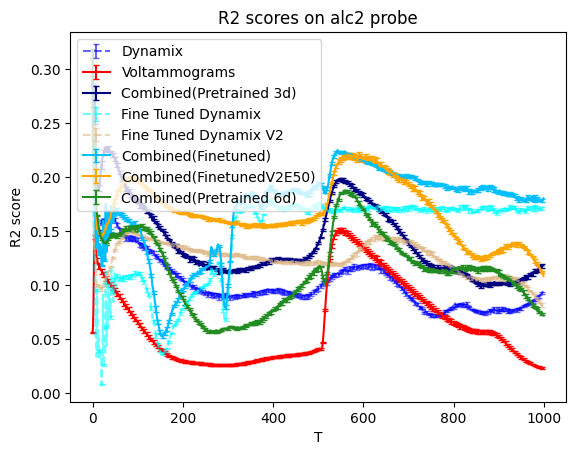

In [25]:
kfold_act = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_act/kfold_reg_over_t_fullAct_alc2.npy",allow_pickle=True).item()
kfold_actFine = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/alc2_finetune_0/kfold_reg_over_t_fullActFine_alc2.npz",allow_pickle=True)
kfold_actFine2E50 = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/alc2_finetune_2_epoch50/kfold_reg_over_t_fullActivationsFineTune2E50_alc2.npz",allow_pickle=True)
kfold_raw = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_volta/kfold_reg_over_t_fullVolta_alc2.npy",allow_pickle=True).item()
kfold_combined = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_combined/kfold_reg_over_t_fullCombined_alc2.npz",allow_pickle=True)
kfold_combinedFine = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/alc2_finetune_0/kfold_reg_over_t_fullCombinedFine_alc2.npz",allow_pickle=True)
kfold_combined6d = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/alc2_combined6d/kfold_reg_over_t_fullCombined6d_alc2.npz",allow_pickle=True)
kfold_combinedFine2E50 = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/alc2_finetune_2_epoch50/kfold_reg_over_t_fullCombinedFineTune2E50_alc2.npz",allow_pickle=True)

m_act, s_act = sem_stat(kfold_act)
m_actF, s_actF = sem_stat(kfold_actFine)
m_actF2, s_actF2 = sem_stat(kfold_actFine2E50)
m_raw, s_raw = sem_stat(kfold_raw)
m_comb, s_comb = sem_stat(kfold_combined)
m_comb6d, s_comb6d = sem_stat(kfold_combined6d)
m_combF, s_combF = sem_stat(kfold_combinedFine)
m_combF2, s_combF2 = sem_stat(kfold_combinedFine2E50)

plt.title(f"R2 scores on alc2 probe")
plt.errorbar(np.arange(T), m_act, yerr=s_act, color='blue', label='Dynamix',
                errorevery=5, capsize=2, alpha=0.6, ls='--')
plt.errorbar(np.arange(T), m_raw, yerr=s_raw, color='r', label='Voltammograms',
                errorevery=5, capsize=2)
plt.errorbar(np.arange(T), m_comb, yerr=s_comb, color='navy', label='Combined(Pretrained 3d)',
                errorevery=5, capsize=2)
plt.errorbar(np.arange(T), m_actF, yerr=s_actF, color='cyan', label='Fine Tuned Dynamix',
                errorevery=5, capsize=2, alpha=0.6, ls='--')
plt.errorbar(np.arange(T), m_actF2, yerr=s_actF2, color='burlywood', label='Fine Tuned Dynamix V2',
                errorevery=5, capsize=2, alpha=0.6, ls='--')
plt.errorbar(np.arange(T), m_combF, yerr=s_combF, color='deepskyblue', label='Combined(Finetuned)',
                errorevery=5, capsize=2)
plt.errorbar(np.arange(T), m_combF2, yerr=s_combF2, color='orange', label='Combined(FinetunedV2E50)',
                errorevery=5, capsize=2)
plt.errorbar(np.arange(T), m_comb6d, yerr=s_comb6d, color='forestgreen', label='Combined(Pretrained 6d)',
                errorevery=5, capsize=2)

plt.ylabel("R2 score")
plt.xlabel("T")
plt.legend()
plt.savefig(f'./plots_ridgereg/r2_fulltimeFinetune_alc2')
plt.show()

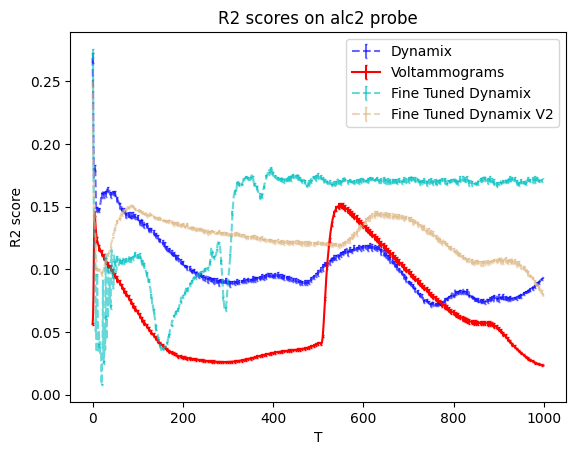

In [28]:
plt.title(f"R2 scores on alc2 probe")
plt.errorbar(np.arange(T), m_act, yerr=s_act, color='blue', label='Dynamix',
                errorevery=5, capsize=1, alpha=0.6, ls='--')
plt.errorbar(np.arange(T), m_raw, yerr=s_raw, color='r', label='Voltammograms',
                errorevery=5, capsize=1)
plt.errorbar(np.arange(T), m_actF, yerr=s_actF, color='c', label='Fine Tuned Dynamix',
                errorevery=5, capsize=1, alpha=0.6, ls='--')
plt.errorbar(np.arange(T), m_actF2, yerr=s_actF2, color='burlywood', label='Fine Tuned Dynamix V2',
                errorevery=5, capsize=1, alpha=0.6, ls='--')
plt.ylabel("R2 score")
plt.xlabel("T")
plt.legend()
plt.savefig(f'./plots_ridgereg/r2_fulltimeActivationsFinetune_alc2')
plt.show()

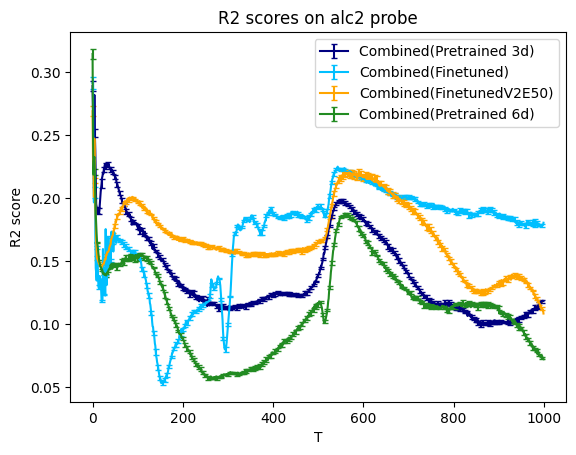

In [ ]:
plt.title(f"R2 scores on alc2 probe")

plt.errorbar(np.arange(T), m_comb, yerr=s_comb, color='navy', label='Combined(Pretrained 3d)',
                errorevery=5, capsize=2)
plt.errorbar(np.arange(T), m_combF, yerr=s_combF, color='deepskyblue', label='Combined(Finetuned)',
                errorevery=5, capsize=2)
plt.errorbar(np.arange(T), m_combF2, yerr=s_combF2, color='orange', label='Combined(FinetunedV2E50)',
                errorevery=5, capsize=2)
plt.errorbar(np.arange(T), m_comb6d, yerr=s_comb6d, color='forestgreen', label='Combined(Pretrained 6d)',
                errorevery=5, capsize=2)
plt.ylabel("R2 score")
plt.xlabel("T")
plt.legend()
plt.savefig(f'./plots_ridgereg/r2_fulltimeCombinedFinetune_alc2')
plt.show()

In [ ]:
probes_short = ['alc1','alc2','alc3_t1','alc3_t2', 'alc4_t1', 'alc4_t2', 'alc4_t3']
kfold_act_all_m = []
kfold_act_all_s = []
kfold_raw_all_m = []
kfold_raw_all_s = []
kfold_comb_all_m = []
kfold_comb_all_s = []
for probe in probes_short:
    kfold_act = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_act/kfold_reg_over_t_fullAct_{probe}.npy",allow_pickle=True).item()
    kfold_raw = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_volta/kfold_reg_over_t_fullVolta_{probe}.npy",allow_pickle=True).item()
    kfold_combined = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_combined/kfold_reg_over_t_fullCombined_{probe}.npz",allow_pickle=True)

    m_act, s_act = sem_stat(kfold_act)
    m_raw, s_raw = sem_stat(kfold_raw)
    m_comb, s_comb = sem_stat(kfold_combined)
    kfold_act_all_m.append(m_act)
    kfold_act_all_s.append(s_act)
    kfold_raw_all_m.append(m_raw)
    kfold_raw_all_s.append(s_raw)
    kfold_comb_all_m.append(m_comb)
    kfold_comb_all_s.append(s_comb)
    plt.title(f"R2 scores on {probe} probe, voltammograms vs dynamix activations")

    plt.errorbar(np.arange(T), m_act, yerr=s_act, color='C0', label='act',
                errorevery=5, capsize=2)
    plt.errorbar(np.arange(T), m_raw, yerr=s_raw, color='r', label='raw',
                errorevery=5, capsize=2)
    plt.errorbar(np.arange(T), m_comb, yerr=s_comb, color='m', label='combined',
                errorevery=5, capsize=2)
    plt.ylabel("R2 score")
    plt.xlabel("T")
    plt.legend()
    plt.savefig(f'./plots_ridgereg/r2_fulltime_{probe}')
    plt.show()


    

FileNotFoundError: [Errno 2] No such file or directory: '/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_act/kfold_reg_over_t_fullAct_a.npy'

In [7]:
np.array(np.mean(kfold_act_all_m, axis=0)).shape

(1000,)

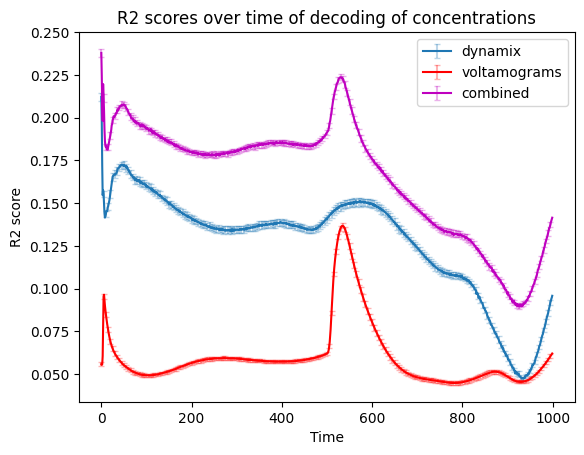

In [14]:
from matplotlib.pyplot import errorbar
import matplotlib.colors as mcolors
plt.title("R2 scores over time of decoding of concentrations")



plt.errorbar(np.arange(T), np.mean(kfold_act_all_m,axis=0), yerr=np.mean(kfold_act_all_s,axis=0),
             color='C0', ecolor=mcolors.to_rgba('C0', alpha=0.3), label='dynamix',
             errorevery=5, capsize=2)

plt.errorbar(np.arange(T), np.mean(kfold_raw_all_m,axis=0), yerr=np.mean(kfold_raw_all_s,axis=0),
             color='r', ecolor=mcolors.to_rgba('r', alpha=0.3), label='voltamograms',
             errorevery=5, capsize=2)

plt.errorbar(np.arange(T), np.mean(kfold_comb_all_m,axis=0), yerr=np.mean(kfold_comb_all_s,axis=0),
             color='m', ecolor=mcolors.to_rgba('m', alpha=0.3), label='combined',
             errorevery=5, capsize=2)

plt.ylabel("R2 score")
plt.xlabel("Time")
plt.legend()
plt.legend()

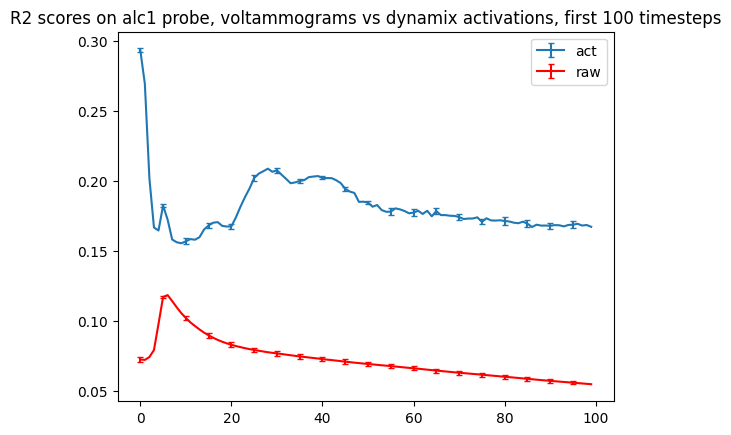

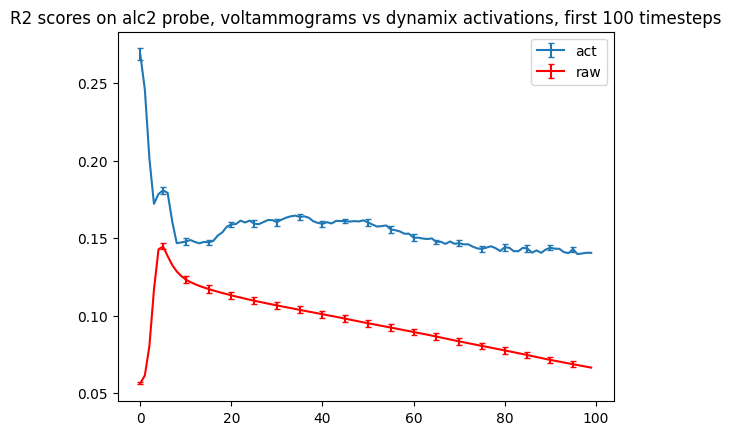

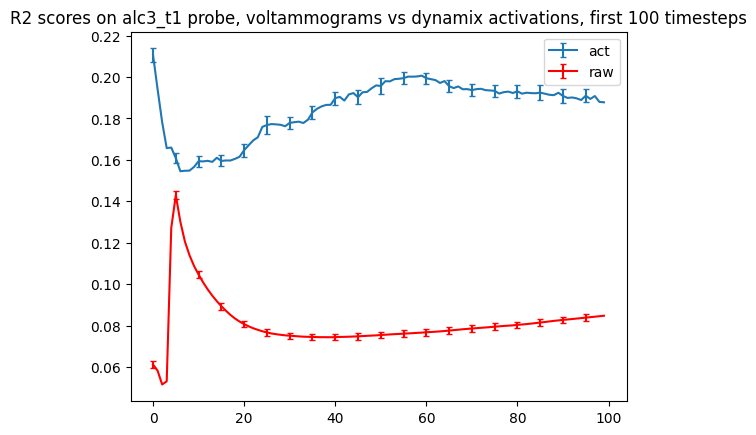

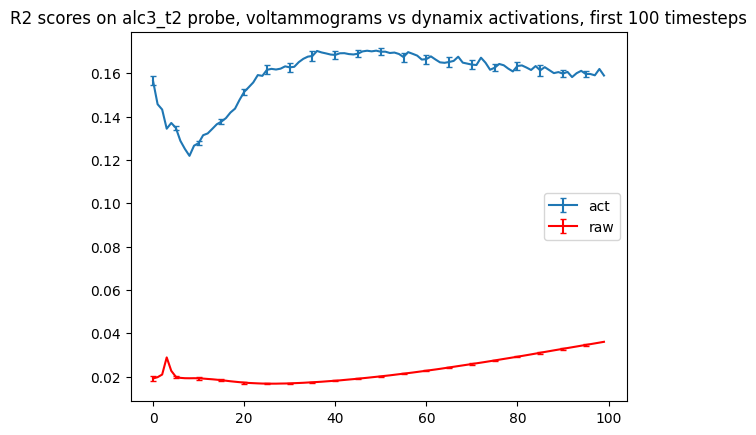

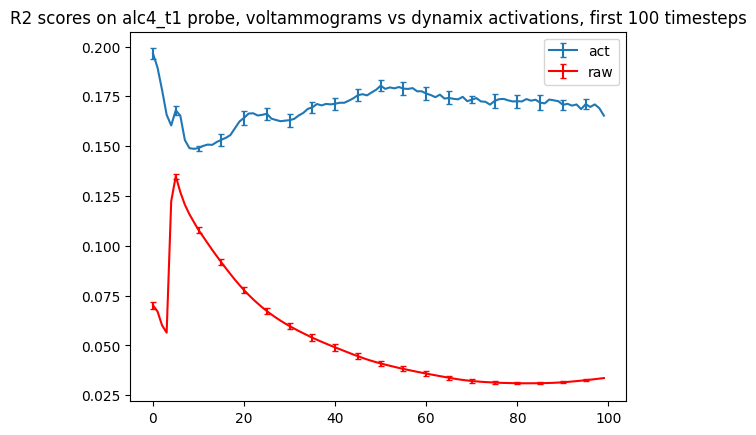

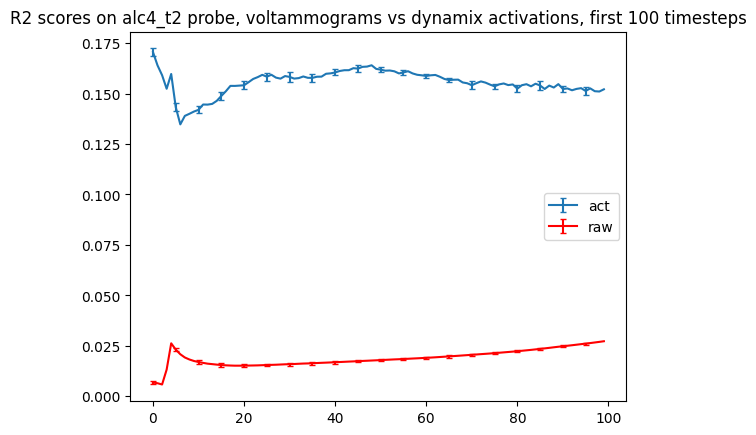

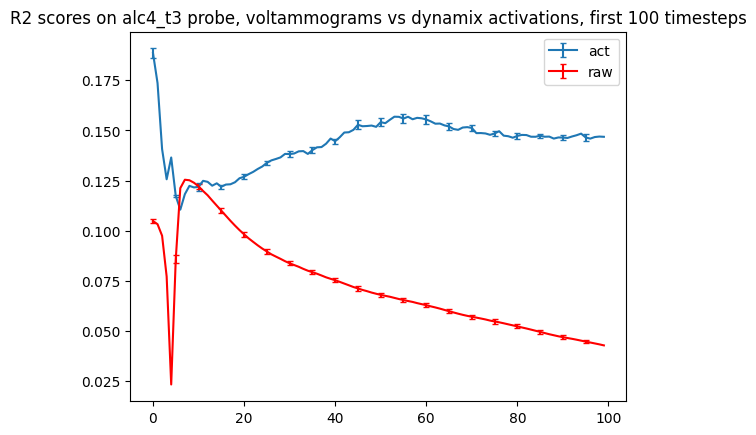

In [9]:
for probe in probes_short:
    kfold_act = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_reg_over_t_fullAct_{probe}.npy",allow_pickle=True).item()
    kfold_raw = np.load(f"/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/kfold_reg_over_t_fullVolta_{probe}.npy",allow_pickle=True).item()

    m_act, s_act = sem_stat(kfold_act)
    m_raw, s_raw = sem_stat(kfold_raw)
    plt.title(f"R2 scores on {probe} probe, voltammograms vs dynamix activations, first 100 timesteps")
    plt.errorbar(np.arange(100), m_act[:100], yerr=s_act[:100], color='C0', label='act',
                errorevery=5, capsize=2)
    plt.errorbar(np.arange(100), m_raw[:100], yerr=s_raw[:100], color='r', label='raw',
                errorevery=5, capsize=2)
    plt.legend()
    plt.savefig(f'./plots_ridgereg/r2_firsthun_{probe}')
    plt.show()

In [10]:
m_act_alc1_rmse, s_act_alc1_rmse = sem_stat(kfold_act_alc1, stat='rmse_norm')
m_raw_alc1_rmse, s_raw_alc1_rmse = sem_stat(kfold_raw_alc1, stat='rmse_norm')

NameError: name 'kfold_act_alc1' is not defined

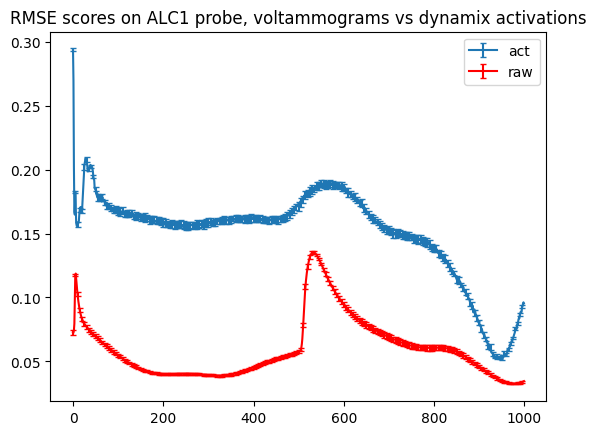

In [ ]:
from matplotlib.pyplot import errorbar

plt.title("RMSE scores on ALC1 probe, voltammograms vs dynamix activations")

plt.errorbar(np.arange(T), m_act_alc1, yerr=s_act_alc1, color='C0', label='act',
             errorevery=5, capsize=2)
plt.errorbar(np.arange(T), m_raw_alc1, yerr=s_raw_alc1, color='r', label='raw',
             errorevery=5, capsize=2)
plt.legend()

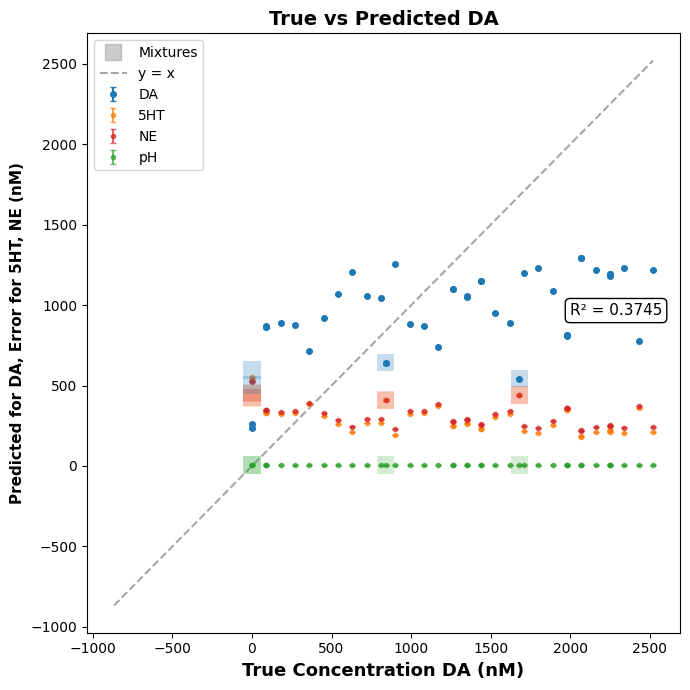

alc1 | DA: t_peak=516, R²=0.3745


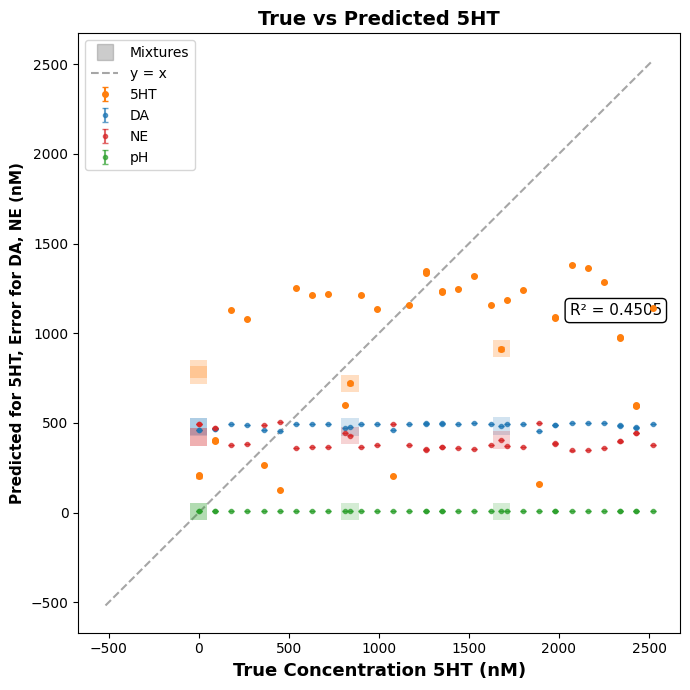

alc1 | 5HT: t_peak=7, R²=0.4505


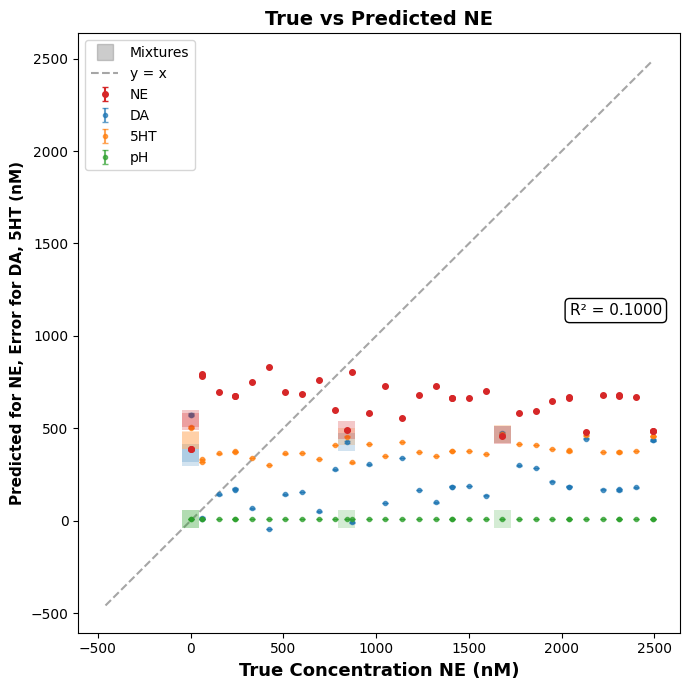

alc1 | NE: t_peak=3, R²=0.1000


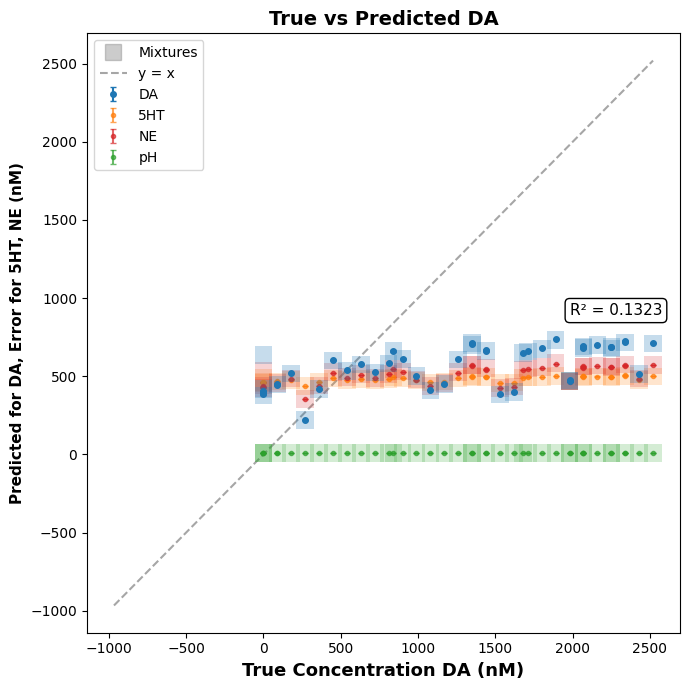

alc2 | DA: t_peak=508, R²=0.1323


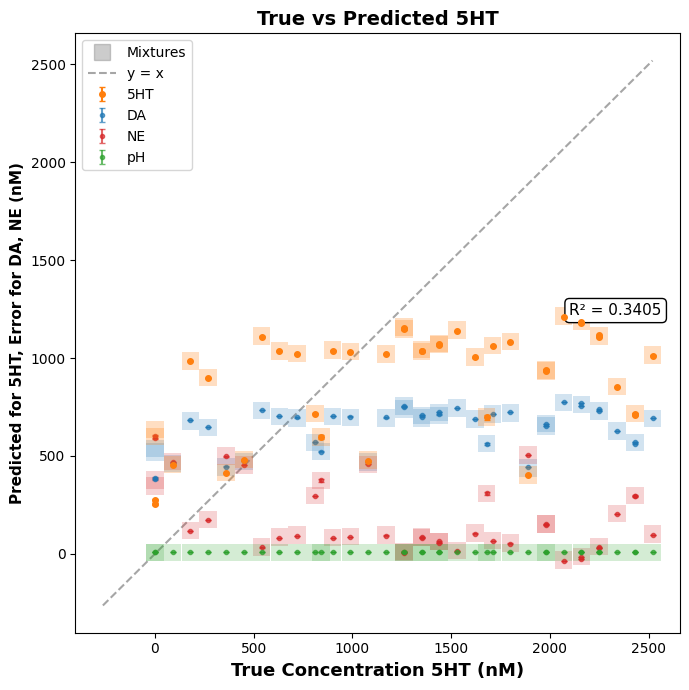

alc2 | 5HT: t_peak=6, R²=0.3405


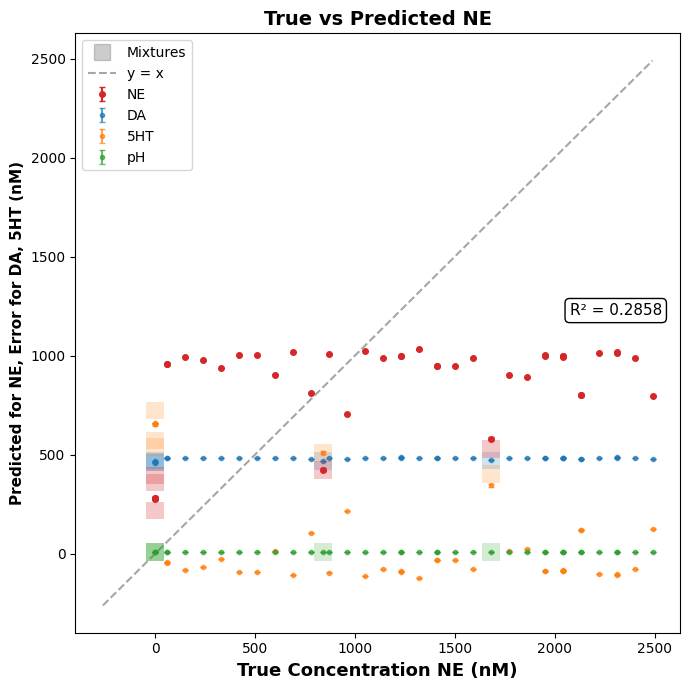

alc2 | NE: t_peak=537, R²=0.2858


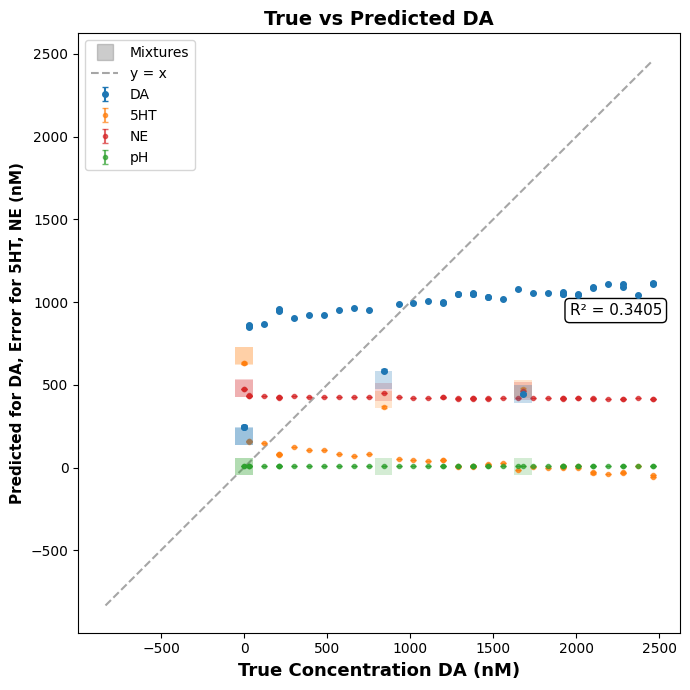

alc3_t1 | DA: t_peak=511, R²=0.3405


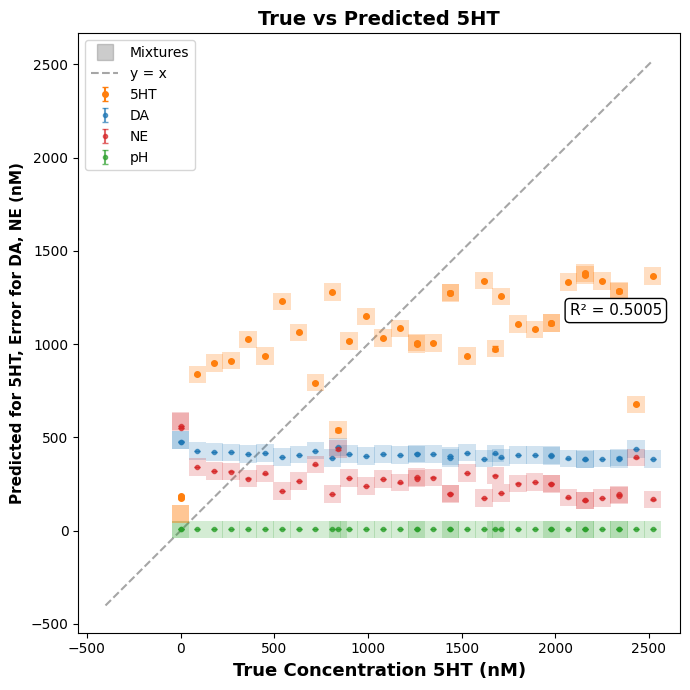

alc3_t1 | 5HT: t_peak=5, R²=0.5005


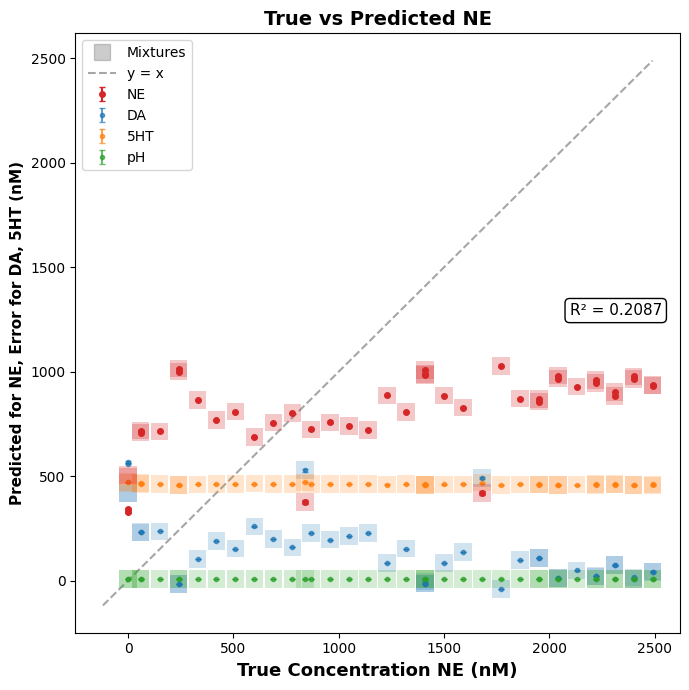

alc3_t1 | NE: t_peak=860, R²=0.2087


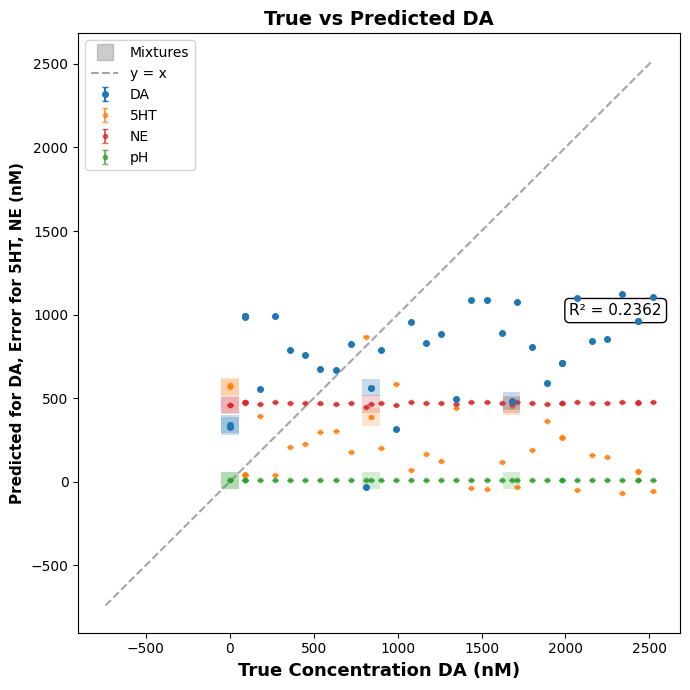

alc3_t2 | DA: t_peak=525, R²=0.2362


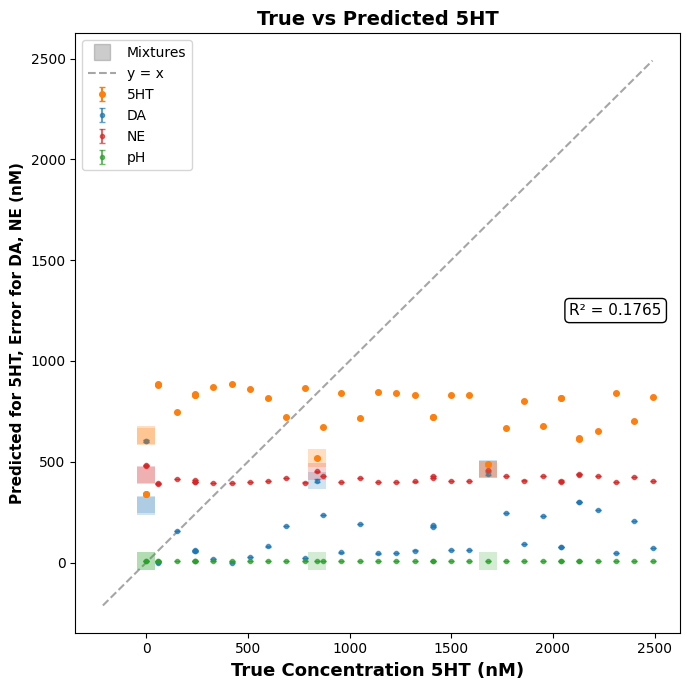

alc3_t2 | 5HT: t_peak=534, R²=0.1765


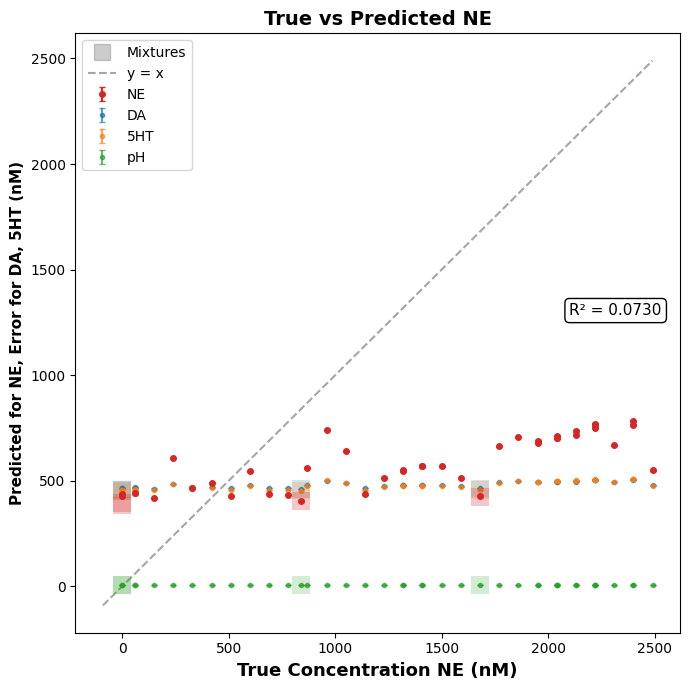

alc3_t2 | NE: t_peak=1, R²=0.0730


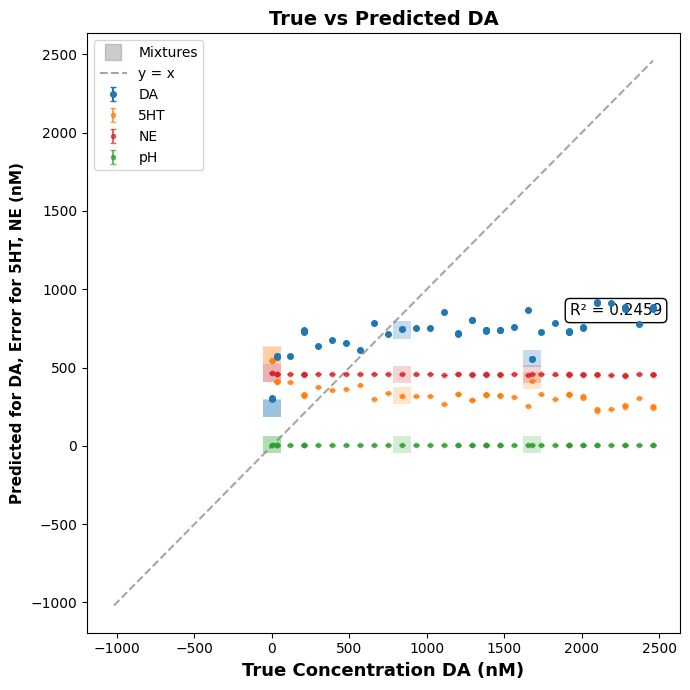

alc4_t1 | DA: t_peak=505, R²=0.2459


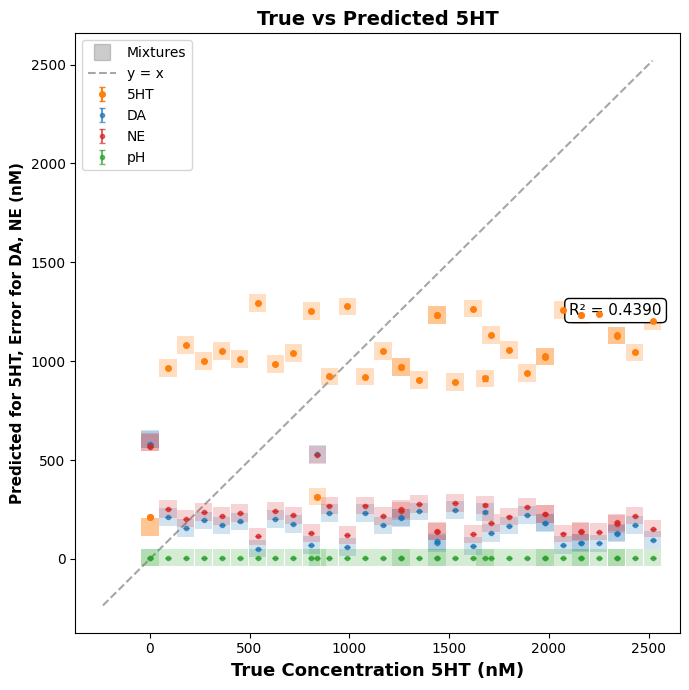

alc4_t1 | 5HT: t_peak=554, R²=0.4390


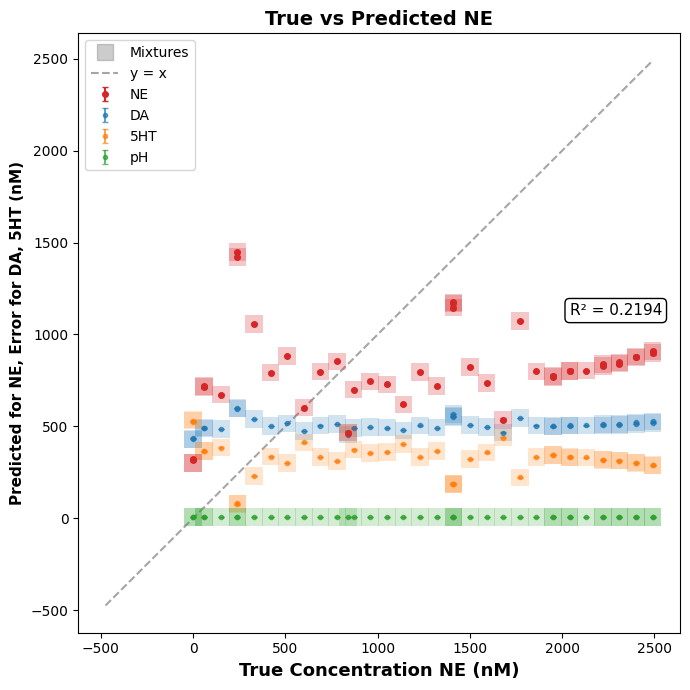

alc4_t1 | NE: t_peak=0, R²=0.2194


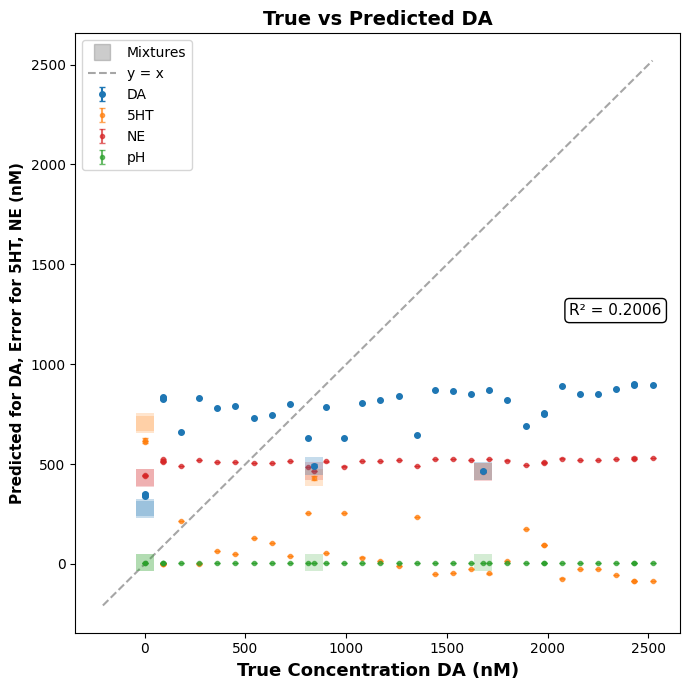

alc4_t2 | DA: t_peak=520, R²=0.2006


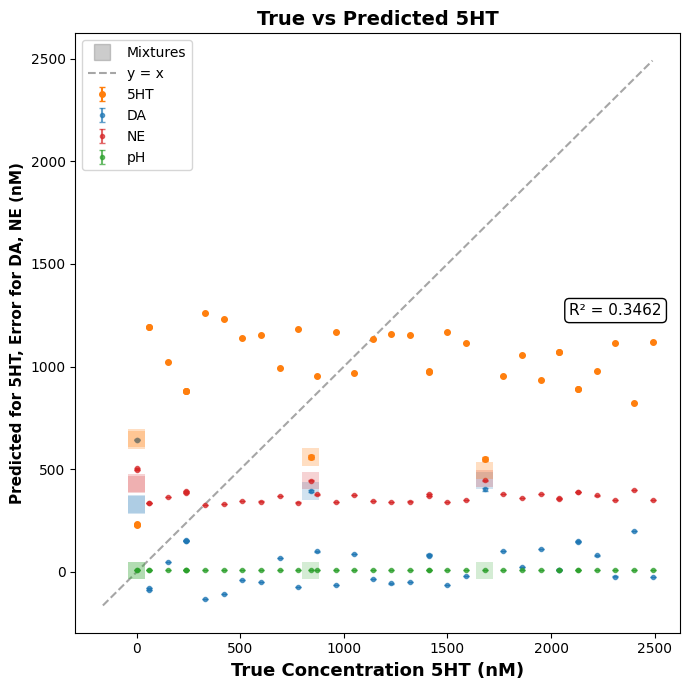

alc4_t2 | 5HT: t_peak=528, R²=0.3462


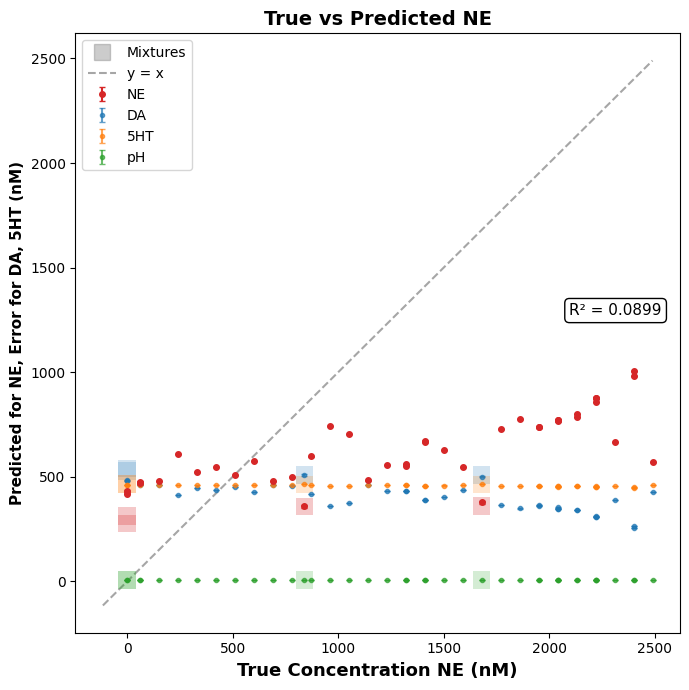

alc4_t2 | NE: t_peak=857, R²=0.0899


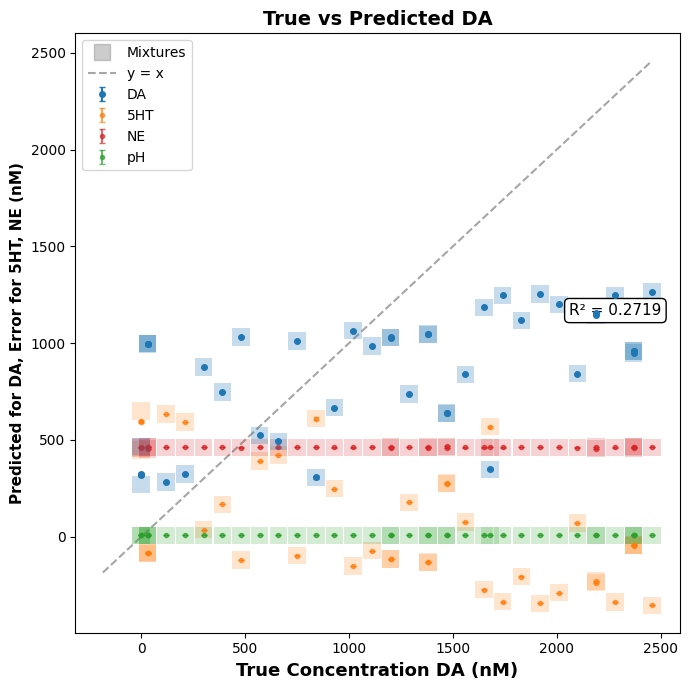

alc4_t3 | DA: t_peak=535, R²=0.2719


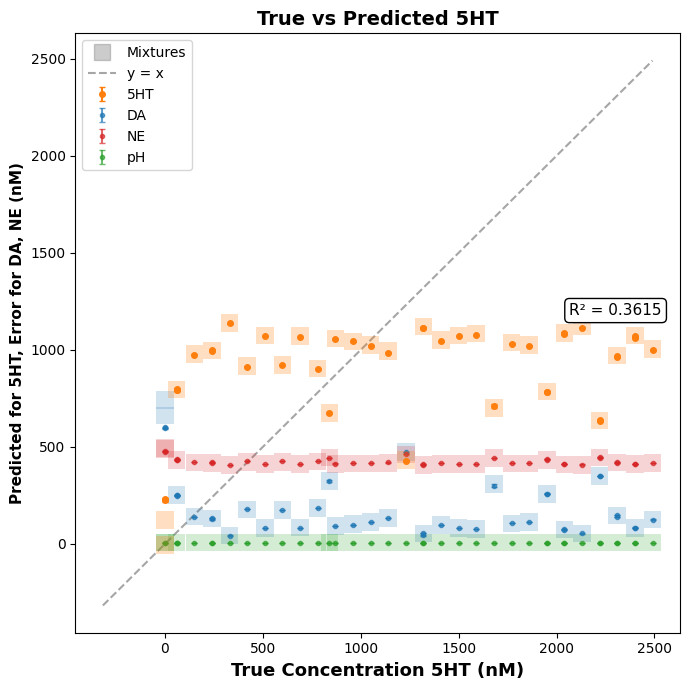

alc4_t3 | 5HT: t_peak=8, R²=0.3615


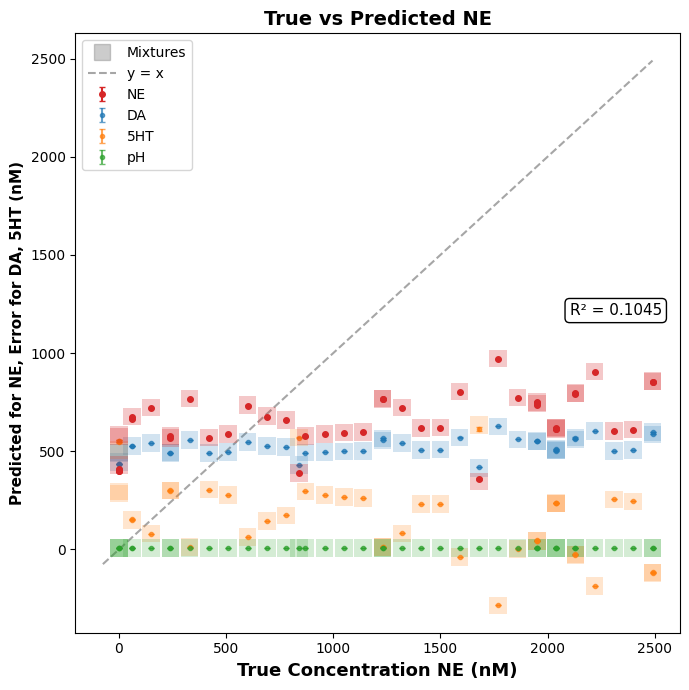

alc4_t3 | NE: t_peak=821, R²=0.1045


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

TARGET_NAMES = ['DA', '5HT', 'NE', 'pH']
TARGET_COLORS = {'DA': 'C0', '5HT': 'C1', 'NE': 'C3', 'pH': 'C2'}  # blue, orange, red, green
T = 1000


def aggregate_folds(kfold):
    """
    Stack y_true and y_pred across folds.
    Returns:
      y_true: (N_total, 4)         — real units
      y_pred: (T, N_total, 4)      — real units, all time steps
    """
    y_true = np.concatenate(kfold['y_true_folds'], axis=0)
    # y_pred_folds[f] has shape (T, N_te_fold, 4); concat along the sample axis
    y_pred = np.concatenate(kfold['y_pred_folds'], axis=1)
    return y_true, y_pred


def aggregate_by_condition(y_true_target, y_pred_target):
    """
    Group samples by unique true-concentration value for one target.
    Returns arrays: (unique_conc, mean_pred, sem_pred).
    """
    unique_c = np.unique(y_true_target)
    mean_p = np.zeros_like(unique_c, dtype=float)
    sem_p  = np.zeros_like(unique_c, dtype=float)
    for i, c in enumerate(unique_c):
        mask = y_true_target == c
        vals = y_pred_target[mask]
        mean_p[i] = vals.mean()
        sem_p[i]  = vals.std(ddof=1) / np.sqrt(len(vals)) if len(vals) > 1 else 0.0
    return unique_c, mean_p, sem_p


def plot_true_vs_pred(kfold, target_idx, probe_name, ax=None):
    target_name = TARGET_NAMES[target_idx]
    target_color = TARGET_COLORS[target_name]

    y_true_all, y_pred_all = aggregate_folds(kfold)

    mean_r2_per_tgt = kfold['r2_per_tgt'].mean(axis=0)
    t_peak = int(mean_r2_per_tgt[:, target_idx].argmax())
    r2_peak = mean_r2_per_tgt[t_peak, target_idx]

    y_pred_t = y_pred_all[t_peak]

    nm_nonzero = (y_true_all[:, :3] > 0).sum(axis=1)
    is_mixture = nm_nonzero > 1

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))

    # --- target analyte points ---
    x_t = y_true_all[:, target_idx]
    p_t = y_pred_t[:, target_idx]
    uc, mp, sp = aggregate_by_condition(x_t, p_t)
    ax.errorbar(uc, mp, yerr=sp, fmt='o', color=target_color, ms=4,
                capsize=2, label=target_name, zorder=3)
    if is_mixture.any():
        uc_m, mp_m, sp_m = aggregate_by_condition(
            y_true_all[is_mixture, target_idx], p_t[is_mixture]
        )
        ax.scatter(uc_m, mp_m, s=160, marker='s',
                   facecolor=target_color, edgecolor='none', alpha=0.25, zorder=2)

    # --- y = x reference line (covers full extent of data) ---
    lim_min = min(x_t.min(), p_t.min())
    lim_max = max(x_t.max(), p_t.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], '--', color='gray',
            lw=1.5, alpha=0.7, label='y = x', zorder=1)

    ax.text(0.97, 0.55, f'R² = {r2_peak:.4f}',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'),
            fontsize=11)

    # --- off-target predictions ---
    for j, jname in enumerate(TARGET_NAMES):
        if j == target_idx:
            continue
        p_j = y_pred_t[:, j]
        uc_j, mp_j, sp_j = aggregate_by_condition(x_t, p_j)
        ax.errorbar(uc_j, mp_j, yerr=sp_j, fmt='o', color=TARGET_COLORS[jname],
                    ms=3, capsize=2, label=jname, alpha=0.7, zorder=1)
        if is_mixture.any():
            uc_jm, mp_jm, sp_jm = aggregate_by_condition(
                y_true_all[is_mixture, target_idx], p_j[is_mixture]
            )
            ax.scatter(uc_jm, mp_jm, s=160, marker='s',
                       facecolor=TARGET_COLORS[jname], edgecolor='none',
                       alpha=0.2, zorder=1)

    handles, labels = ax.get_legend_handles_labels()
    mix_handle = plt.Line2D([], [], marker='s', color='gray', alpha=0.4,
                            markersize=12, linestyle='', label='Mixtures')
    ax.legend(handles=[mix_handle] + handles, loc='upper left', fontsize=10)

    ax.set_xlabel(f'True Concentration {target_name} (nM)',
                  fontsize=13, fontweight='bold')
    other_names = [n for n in TARGET_NAMES if n != target_name and n != 'pH']
    ax.set_ylabel(f'Predicted for {target_name}, Error for {", ".join(other_names)} (nM)',
                  fontsize=11, fontweight='bold')
    ax.set_title(f'True vs Predicted {target_name}', fontsize=14, fontweight='bold')
    return t_peak, r2_peak


# --- driver: per-probe, per-analyte plots ---
base = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise"
out_dir = "./plots_ridgereg/inceptlike_volta"

for probe in probes_short:
    # use .npz if you switched, .npy if you kept np.save
    kfold_act = np.load(f"{base}/kfold_reg_over_t_fullVolta_{probe}.npz",
                        allow_pickle=True)

    for target_idx, tname in enumerate(TARGET_NAMES):
        if tname == 'pH':
            continue   # skip pH plot; comment this out if you want it
        fig, ax = plt.subplots(figsize=(7, 7))
        t_peak, r2 = plot_true_vs_pred(kfold_act, target_idx, probe, ax=ax)
        plt.tight_layout()
        plt.savefig(f'{out_dir}/{probe}_pred_{tname}_t{t_peak}.png', dpi=120)
        plt.show()
        print(f"{probe} | {tname}: t_peak={t_peak}, R²={r2:.4f}")

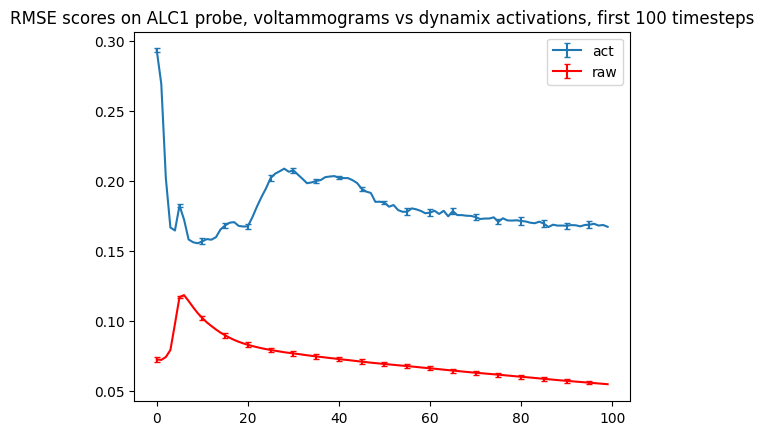

In [ ]:
plt.title("RMSE scores on ALC1 probe, voltammograms vs dynamix activations, first 100 timesteps")
plt.errorbar(np.arange(100), m_act_alc1[:100], yerr=s_act_alc1[:100], color='C0', label='act',
             errorevery=5, capsize=2)
plt.errorbar(np.arange(100), m_raw_alc1[:100], yerr=s_raw_alc1[:100], color='r', label='raw',
             errorevery=5, capsize=2)
plt.legend()

# Raw Voltammogram Classification

In [ ]:
acc_over_t_full_raw_volta = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_full_raw_volta.npy")
acc_over_t_full_raw_volta_mean = acc_over_t_full_raw_volta.mean(axis=0)
acc_over_t_full_raw_volta_SEM = acc_over_t_full_raw_volta.std(axis=0)/np.sqrt(acc_over_t_full_raw_volta.shape[0])

In [ ]:
from scipy.io import loadmat
weight_3d = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155/alc1/155Vs/10Hz/2025_09_02__RIGINM__5HT__155Vs_10Hz__ALC_INM001_01b/5HT/weights_3d.npy")
volta = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155/alc1/155Vs/10Hz/2025_09_02__RIGINM__5HT__155Vs_10Hz__ALC_INM001_01b/5HT/voltammograms.npy")
volta_mat = loadmat("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155/alc1/155Vs/10Hz/2025_09_02__RIGINM__5HT__155Vs_10Hz__ALC_INM001_01b/5HT/voltammograms.mat")
labels = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155/alc1/155Vs/10Hz/2025_09_02__RIGINM__5HT__155Vs_10Hz__ALC_INM001_01b/5HT/labels.npy")
labels_mat = loadmat("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155/alc1/155Vs/10Hz/2025_09_02__RIGINM__5HT__155Vs_10Hz__ALC_INM001_01b/5HT/labels.mat")
print("Activation weight .npy shape: ", weight_3d.shape)
print("Voltammogram .npy shape: ", volta.shape)
print("Voltammogram .mat keys: ", volta_mat.keys())
print("Voltammogram .mat 'voltammogram' key value shape: ", volta_mat['voltammograms'].shape)
print("Labels .npy shape: ", labels.shape)
print("Labels .mat keys: ", labels_mat.keys())

print("Labels .mat 'chemicals' key shape: ", labels_mat['chemicals'].shape)
print("Labels .mat 'labels' key shape", labels_mat['labels'].shape)


Activation weight .npy shape:  (35, 150, 1000, 10)
Voltammogram .npy shape:  (35, 1000, 150)
Voltammogram .mat keys:  dict_keys(['__header__', '__version__', '__globals__', 'voltammograms'])
Voltammogram .mat 'voltammogram' key value shape:  (35, 1)
Labels .npy shape:  (35, 600)
Labels .mat keys:  dict_keys(['__header__', '__version__', '__globals__', 'chemicals', 'labels'])
Labels .mat 'chemicals' key shape:  (1, 4)
Labels .mat 'labels' key shape (35, 1)


In [ ]:
print(acc_over_t_full_raw_volta.shape)

(7, 1000)


Text(0, 0.5, 'Accuracy')

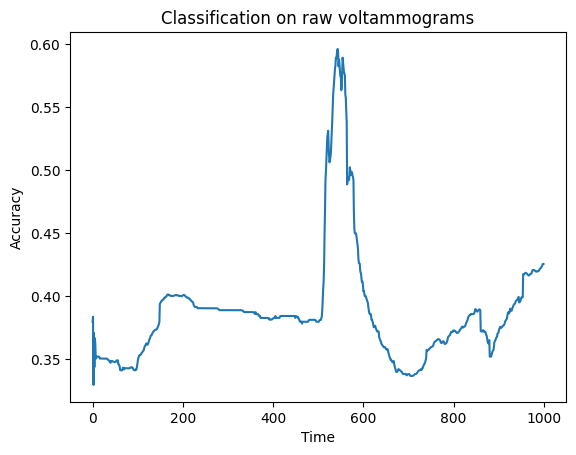

In [ ]:

plt.plot(range(T), acc_over_t_full_raw_volta_mean)
plt.title("Classification on raw voltammograms")
plt.xlabel("Time")
plt.ylabel("Accuracy")

In [ ]:
t_peak_raw = np.argmax(acc_over_t_full_raw_volta_mean)
print(t_peak_raw)
svm_results_raw = loo_svm_tpeak(probe_list=probes,t_peak=t_peak_raw, volta=True)

543
Found 28 paths
Getting pairs collapsed.
Getting raw voltammograms


First activation shape(35, 1000, 1)
First label shape(35, 4)
Activation shape: (847, 1000, 1)
Labels shape: (847, 4)

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW08R03M']
[LOPO] test probes: [np.str_('ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'

ValueError: too many values to unpack (expected 6)

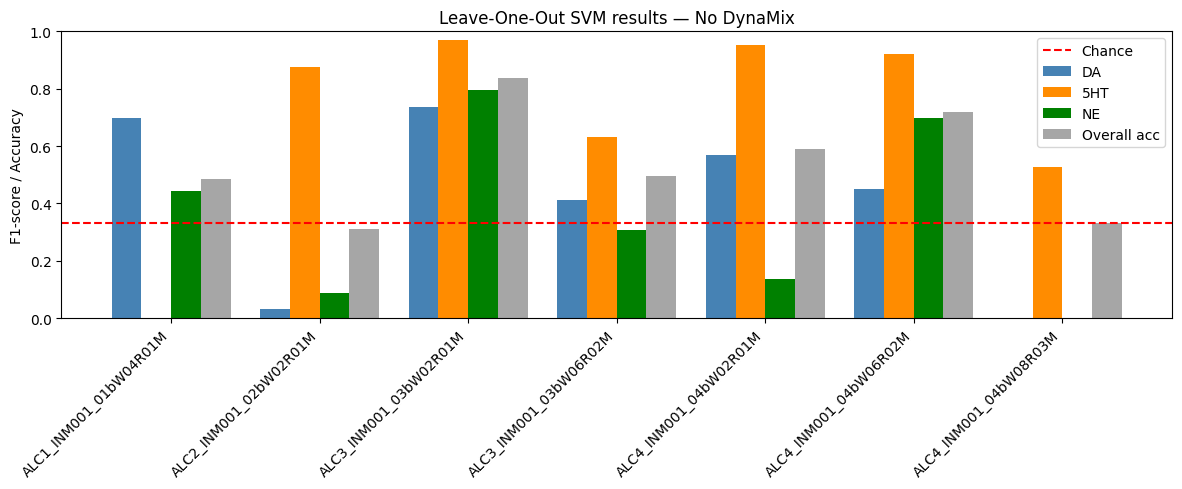

In [ ]:
plot_loo_results(svm_results_raw, model_dim='No')

# On ALC3 probe, confusion matrix compared

In [ ]:
best_probe = 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
weights_paths = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"
train_full, test_full, y_mean_full, y_std_full, _, test_probe_full =  utils.load_activation_data(weights_paths,test_probe=best_probe,collapsed=False,ret_np=True,volta=True)

Found 28 paths
Getting pairs not collapsed.
Getting raw voltammograms
First activation shape(5250, 1000, 1)
First label shape(5250, 4)
Activation shape: (127050, 1000, 1)
Labels shape: (127050, 4)

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 13950 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 13950 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 13950 samples
Total valid samples: 97650
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macro

ValueError: too many values to unpack (expected 6)

t_peak: 537, acc: 0.9354838709677419
              precision    recall  f1-score   support

          DA       1.00      0.90      0.95      4650
         5HT       0.91      1.00      0.95      4650
          NE       0.90      0.90      0.90      4650

    accuracy                           0.94     13950
   macro avg       0.94      0.94      0.94     13950
weighted avg       0.94      0.94      0.94     13950



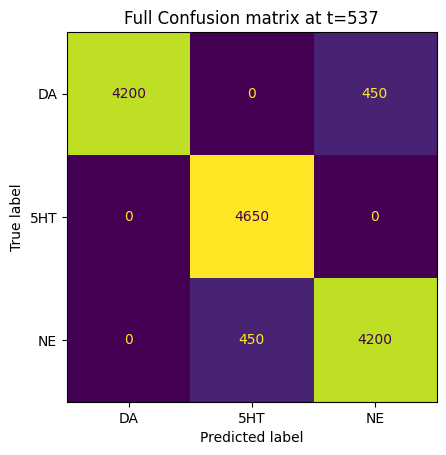

In [ ]:

t_peak_full_raw = np.argmax(acc_over_t_full_raw_volta[2])
print(f"t_peak: {t_peak_full_raw}, acc: {acc_over_t_full_raw_volta[2][t_peak_full_raw]}")
X_tpeak_tr = train_full[0][:,t_peak_full_raw,:]
X_tpeak_test = test_full[0][:,t_peak_full_raw,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full[1])

y_pred_full= clf.predict(X_te_s)

print(classification_report(test_full[1], y_pred_full, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_full[1], y_pred_full)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.title(f"Full Confusion matrix at t={t_peak_full_raw}")
plt.show()

In [ ]:
fold_3d = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_full_3d.npy")
train_full_3d, test_full_3d, y_mean_full_3d, y_std_full_3d, _, test_probe_full =  utils.load_activation_data(weights_paths,test_probe=best_probe,collapsed=False,ret_np=True)

In [ ]:
print(f"Activations train split shape: {train_full_3d[0].shape}")
print(f"Labels train split shape: {train_full_3d[2].shape}")

Activations train split shape: (83700, 1000, 10)
Labels train split shape: (83700, 4)


In [ ]:
fold_3d_mean = fold_3d.mean(axis=0)
fold_3d_SEM = fold_3d.std(axis=0)/np.sqrt(fold_3d.shape[0])
t_peak_3d_kfold = np.argmax(fold_3d_mean)
print(t_peak_3d_kfold)


plt.plot(range(T), acc_over_t_full_raw_volta_mean, color='red',label='raw volta accuracy')
plt.plot(range(T), fold_3d_mean, label='expert activations accuracy mean ')

plt.plot(range(T), acc_over_t_full_raw_volta_SEM, linestyle = '--',  color='red',label='raw volta accuracy SEM')
plt.plot(range(T), fold_3d_SEM, linestyle = '--',color='blue',label='expert activations accuracy SEM')

plt.title("Classification on leave-one-out full N sweep activations vs raw voltammograms")
plt.legend(fontsize=8, loc = 1, handlelength=1.5)
plt.xlabel("Time")

NameError: name 'fold_3d' is not defined

NameError: name 'fold_3d_SEM' is not defined

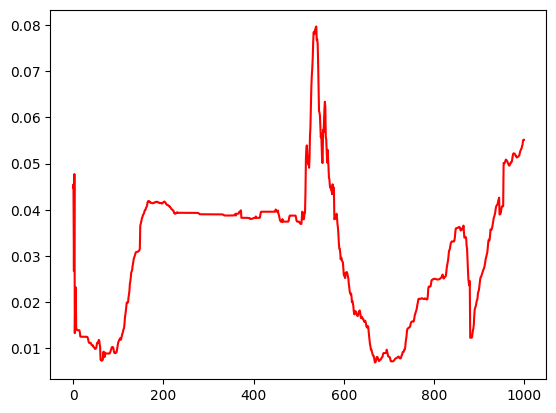

In [ ]:
plt.plot(range(T), acc_over_t_full_raw_volta_SEM, color='red',label='raw volta accuracy SEM')
plt.plot(range(T), fold_3d_SEM, label='expert activations accuracy SEM')

plt.title("Classification on leave-one-out full N sweep activations vs raw voltammograms")
plt.legend()
plt.xlabel("Time")
plt.ylabel("SEM")

In [ ]:
svm_results_3d_kfold = loo_svm_tpeak(probe_list=probes,t_peak=t_peak_3d_kfold, collapsed=False)
plot_loo_results(svm_results_3d_kfold)

NameError: name 't_peak_3d_kfold' is not defined

In [ ]:

t_peak_full_3d_kfold = np.argmax(fold_3d[2])
print(f"t_peak: {t_peak_full_3d_kfold}, acc: {fold_3d[2][t_peak_full_3d_kfold]}")
X_tpeak_tr = train_full_3d[0][:,t_peak_full_3d_kfold,:]
X_tpeak_test = test_full_3d[0][:,t_peak_full_3d_kfold,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full_3d[1])

y_pred_full_3d= clf.predict(X_te_s)

print(classification_report(test_full_3d[1], y_pred_full_3d, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_full[1], y_pred_full_3d)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.title(f"Full Confusion matrix at t={t_peak_full_3d_kfold}")
plt.show()

NameError: name 'fold_3d' is not defined

In [ ]:
plot_model_comparison(svm_results_3d_kfold,svm_results_raw, second_mod='voltammograms')

NameError: name 'plot_model_comparison' is not defined

# Dynamix 3d classification over time results

In [ ]:
acc_over_t_collapsed_over_electrode = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_full_3d.npy")
acc_over_t_full = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/acc_over_t_full_3d.npy")

In [ ]:
print(acc_over_t_collapsed_over_electrode.shape)
print(acc_over_t_collapsed_over_electrode.shape)
print(acc_over_t_collapsed_over_electrode.shape)

NameError: name 'fold_3d_mean' is not defined

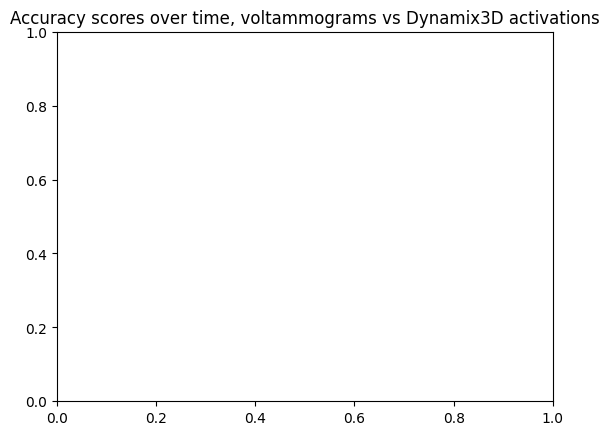

In [ ]:
from matplotlib.pyplot import errorbar
import matplotlib.colors as mcolors
plt.title("Accuracy scores over time, voltammograms vs Dynamix3D activations")



plt.errorbar(np.arange(T), fold_3d_mean, yerr=fold_3d_SEM,
             color='C0', ecolor=mcolors.to_rgba('C0', alpha=0.3), label='act',
             errorevery=5, capsize=2)

plt.errorbar(np.arange(T), acc_over_t_full_raw_volta_mean, yerr=acc_over_t_full_raw_volta_SEM,
             color='r', ecolor=mcolors.to_rgba('r', alpha=0.3), label='volta',
             errorevery=5, capsize=2)
plt.ylabel("Accuracy score")
plt.xlabel("T")
plt.legend()

Text(0, 0.5, 'Accuracy')

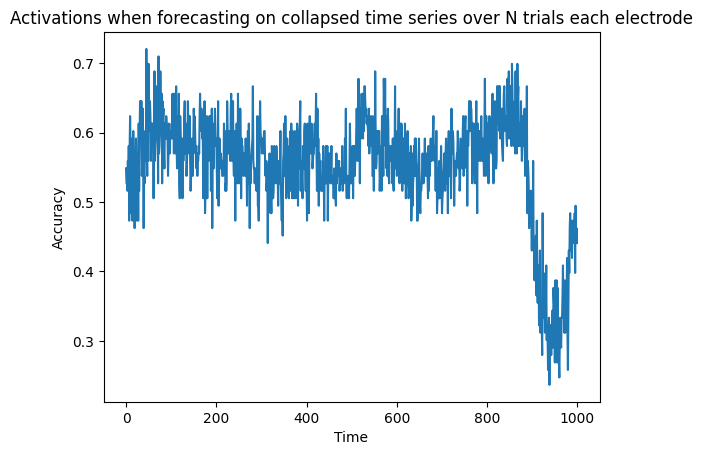

In [ ]:

plt.errorbar(range(T), acc_over_t_collapsed_over_electrode)
plt.title("Activations when forecasting on collapsed time series over N trials each electrode")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

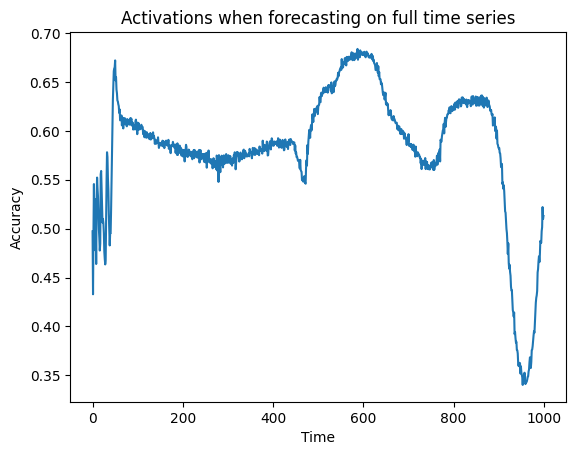

In [ ]:
plt.plot(range(T), acc_over_t_full)
plt.title("Activations when forecasting on full time series")
plt.xlabel("Time")
plt.ylabel("Accuracy")

In [ ]:
weights_paths = "/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF"
train_collapsed_per_electrode, test_collapsed_per_electrode, y_mean_collapsed_per_electrode, y_std_collapsed_per_electrode, mono_dom_list, test_probe_collapsed = utils.load_activation_data(weights_paths,test_probe="ALCIS_155_macroREF__ALC1_INM001_01bW04R01M",ret_np=True)
train_full, test_full, y_mean_full, y_std_full, _, test_probe_full =  utils.load_activation_data(weights_paths,test_probe="ALCIS_155_macroREF__ALC1_INM001_01bW04R01M",collapsed=False,ret_np=True)

Found 28 paths
Getting pairs collapsed.
First activation shape(35, 1000, 10)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 10)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04

t_peak: 587, acc: 0.6837992831541219
              precision    recall  f1-score   support

          DA       0.58      0.83      0.69      4650
         5HT       0.79      0.82      0.81      4650
          NE       0.73      0.40      0.51      4650

    accuracy                           0.68     13950
   macro avg       0.70      0.68      0.67     13950
weighted avg       0.70      0.68      0.67     13950



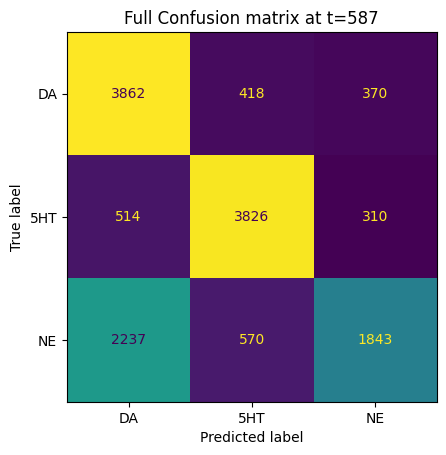

In [ ]:

t_peak_full = np.argmax(acc_over_t_full)
print(f"t_peak: {t_peak_full}, acc: {acc_over_t_full[t_peak_full]}")
X_tpeak_tr = train_full[0][:,t_peak_full,:]
X_tpeak_test = test_full[0][:,t_peak_full,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full[1])

y_pred_full= clf.predict(X_te_s)

print(classification_report(test_full[1], y_pred_full, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_full[1], y_pred_full)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.title(f"Full Confusion matrix at t={t_peak_full}")
plt.show()

t_peak: 45, acc: 0.7204301075268817
              precision    recall  f1-score   support

          DA       0.64      0.87      0.74        31
         5HT       0.81      0.81      0.81        31
          NE       0.70      0.45      0.55        31

    accuracy                           0.71        93
   macro avg       0.72      0.71      0.70        93
weighted avg       0.72      0.71      0.70        93



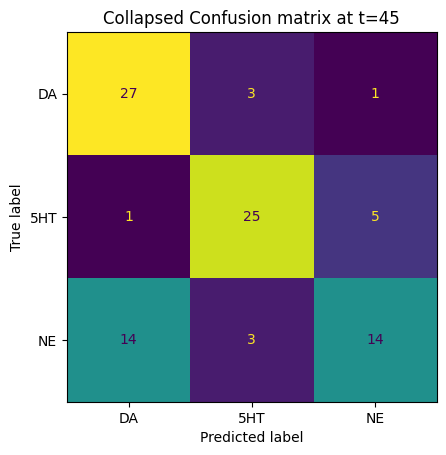

In [ ]:

t_peak_collapsed = np.argmax(acc_over_t_collapsed_over_electrode)
print(f"t_peak: {t_peak_collapsed}, acc: {acc_over_t_collapsed_over_electrode[t_peak_collapsed]}")
X_tpeak_tr = train_collapsed_per_electrode[0][:,t_peak_collapsed,:]
X_tpeak_test = test_collapsed_per_electrode[0][:,t_peak_collapsed,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_collapsed_per_electrode[1])

y_pred_collapsed = clf.predict(X_te_s)

print(classification_report(test_collapsed_per_electrode[1], y_pred_collapsed, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_collapsed_per_electrode[1], y_pred_collapsed)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.title(f"Collapsed Confusion matrix at t={t_peak_collapsed}")
plt.show()

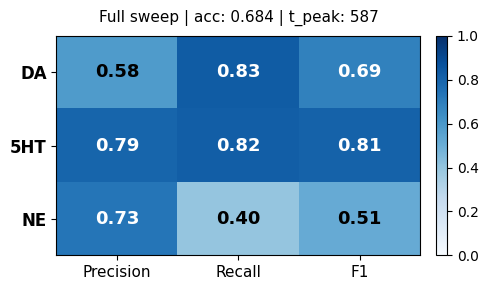

In [ ]:
plot_classification_report(test_full[1], y_pred_full, t_peak_full, acc_over_t_full[t_peak_full], title="Full sweep")


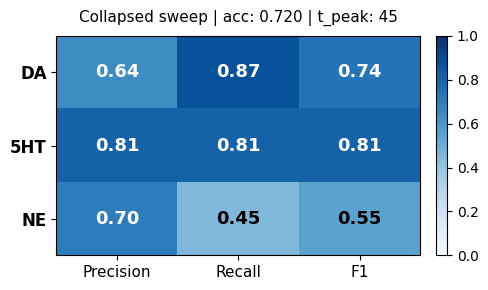

In [ ]:
plot_classification_report(test_collapsed_per_electrode[1], y_pred_collapsed, t_peak_collapsed, acc_over_t_collapsed_over_electrode[t_peak_collapsed], title="Collapsed sweep")

# Top-K time points for classification

In [ ]:
k=8
top_k_t_full = np.argpartition(acc_over_t_full, kth=-k)[-k:]
top_k_t_collapsed = np.argpartition(acc_over_t_collapsed_over_electrode, kth=-k)[-k:]


In [ ]:
X_t_kth_peaks_tr = train_full[0][:,top_k_t_full,:]
X_t_kth_peaks_test = test_full[0][:,top_k_t_full,:]

X_t_kth_peaks_tr.reshape(-1, k*10).shape

(83700, 80)

              precision    recall  f1-score   support

          DA       0.58      0.90      0.70      4650
         5HT       0.80      0.82      0.81      4650
          NE       0.82      0.35      0.49      4650

    accuracy                           0.69     13950
   macro avg       0.73      0.69      0.67     13950
weighted avg       0.73      0.69      0.67     13950



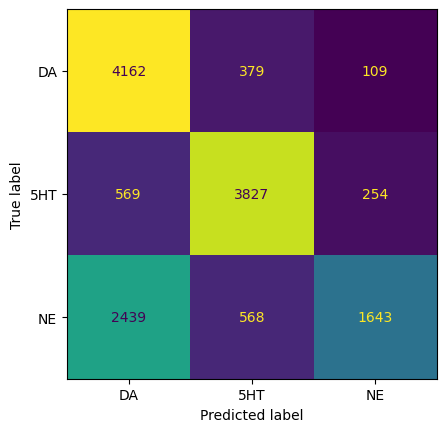

In [ ]:

X_t_kth_peaks_tr = train_full[0][:,top_k_t_full,:]
X_t_kth_peaks_test = test_full[0][:,top_k_t_full,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_t_kth_peaks_tr.reshape(-1, k*10))
X_te_s = scaler.transform(X_t_kth_peaks_test.reshape(-1, k*10))

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full[1])

y_pred_full_topk= clf.predict(X_te_s)

print(classification_report(test_full[1], y_pred_full_topk, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_full[1], y_pred_full_topk)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.show()

In [ ]:
X_t_kth_peaks_tr = train_collapsed_per_electrode[0][:,top_k_t_collapsed,:]
X_t_kth_peaks_test = test_collapsed_per_electrode[0][:,top_k_t_collapsed,:]

X_t_kth_peaks_tr.shape

(558, 8, 10)

In [ ]:
top_k_t_collapsed

array([863, 552,  48, 867, 855,  50,  72,  45])

              precision    recall  f1-score   support

          DA       0.64      0.74      0.69        31
         5HT       0.77      0.77      0.77        31
          NE       0.73      0.61      0.67        31

    accuracy                           0.71        93
   macro avg       0.71      0.71      0.71        93
weighted avg       0.71      0.71      0.71        93



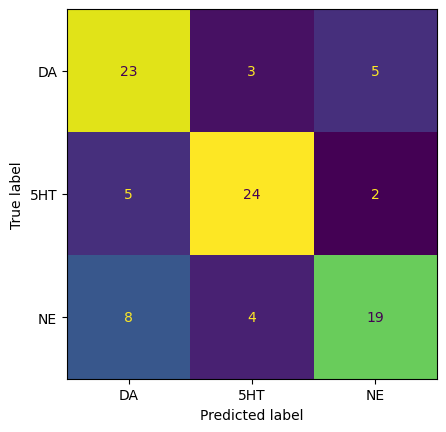

In [ ]:

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_t_kth_peaks_tr.reshape(-1, k*10))
X_te_s = scaler.transform(X_t_kth_peaks_test.reshape(-1, k*10))

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_collapsed_per_electrode[1])

y_pred_collapsed_topk= clf.predict(X_te_s)

print(classification_report(test_collapsed_per_electrode[1], y_pred_collapsed_topk, target_names=['DA','5HT','NE']))

cm = confusion_matrix(test_collapsed_per_electrode[1], y_pred_collapsed_topk)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE'])
disp.plot(colorbar=False)
plt.show()

# Leave-One-Out on probes, 6D vs 3D

In [ ]:
fold_3d = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_collapsed_over_electrode_3d.npy")
fold_6d = np.load("/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/dyna_test/fscv_decoding/time_wise/k_fold_acc_over_t_collapsed_over_electrode_6d.npy")

In [ ]:
fold_3d = fold_3d.mean(axis=0)
fold_6d = fold_6d.mean(axis=0)

Text(0, 0.5, 'Accuracy')

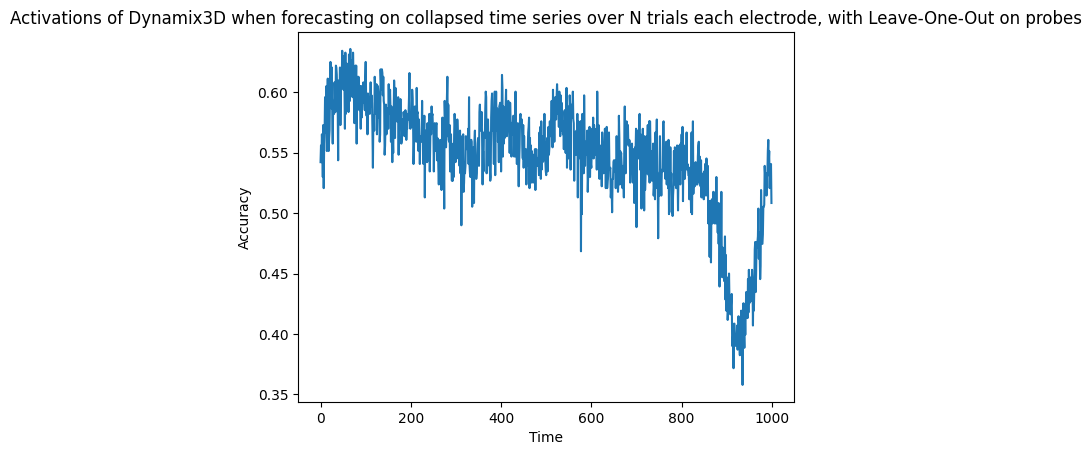

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(T), fold_3d)
plt.title("Activations of Dynamix3D when forecasting on collapsed time series over N trials each electrode, with Leave-One-Out on probes")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

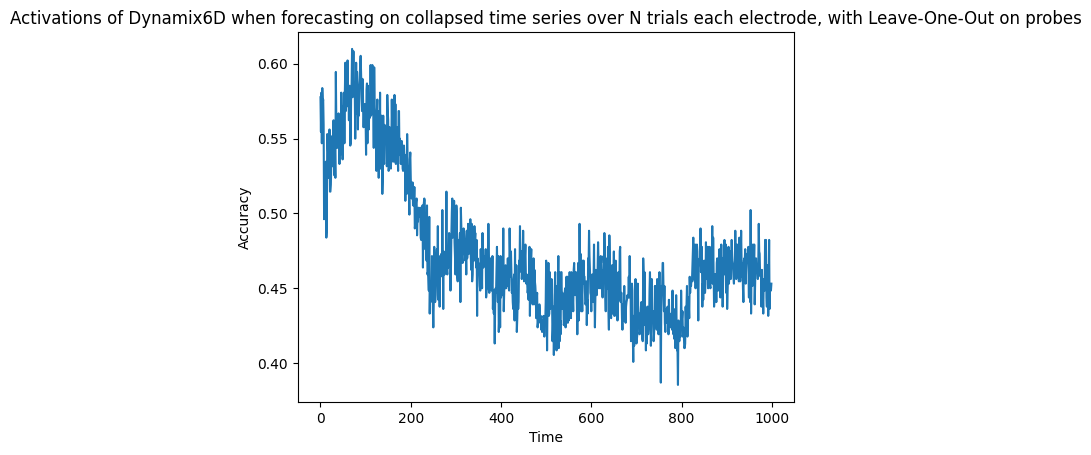

In [ ]:
plt.plot(range(T), fold_6d)
plt.title("Activations of Dynamix6D when forecasting on collapsed time series over N trials each electrode, with Leave-One-Out on probes")
plt.xlabel("Time")
plt.ylabel("Accuracy")

# On maximal descriptive time point

In [ ]:
t_peak_3d = np.argmax(fold_3d)
print(f"for 3D: t_peak {t_peak_3d}, acc {fold_3d[t_peak_3d]}")
t_peak_6d = np.argmax(fold_6d)
print(f"for 6D: t_peak {t_peak_6d}, acc {fold_3d[t_peak_6d]}")

for 3D: t_peak 66, acc 0.6359447004608294
for 6D: t_peak 70, acc 0.619047619047619


In [ ]:
svm_results_3d = loo_svm_tpeak(probe_list=probes,t_peak=t_peak_3d)


Found 28 paths
Getting pairs collapsed.
First activation shape(35, 1000, 10)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 10)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04

In [ ]:
svm_results_6d = loo_svm_tpeak(probe_list=probes,t_peak=t_peak_6d,model_dim=None)


Found 28 paths
Getting pairs collapsed.
First activation shape(35, 1000, 80)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 80)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04

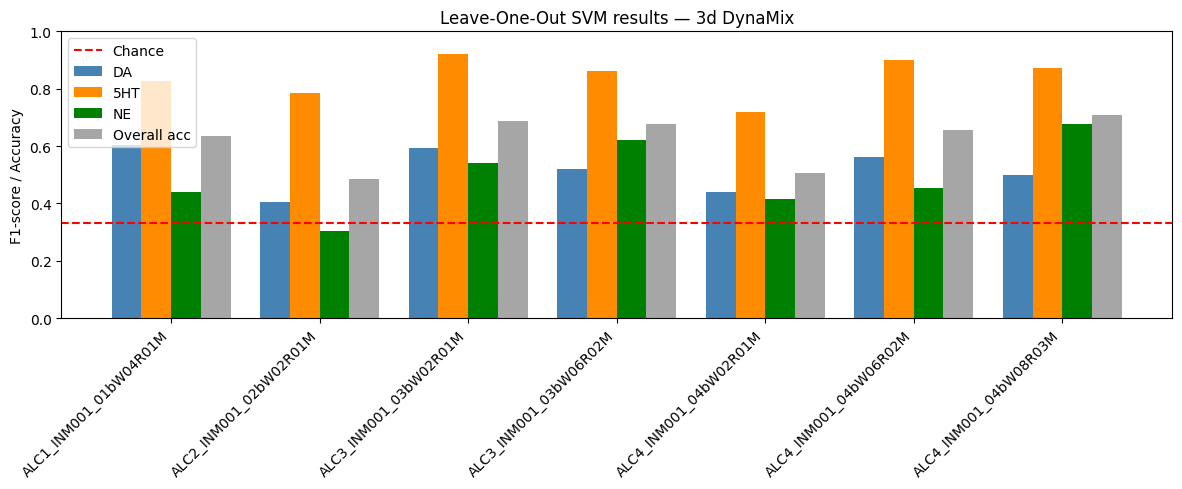

In [ ]:
plot_loo_results(svm_results_3d)

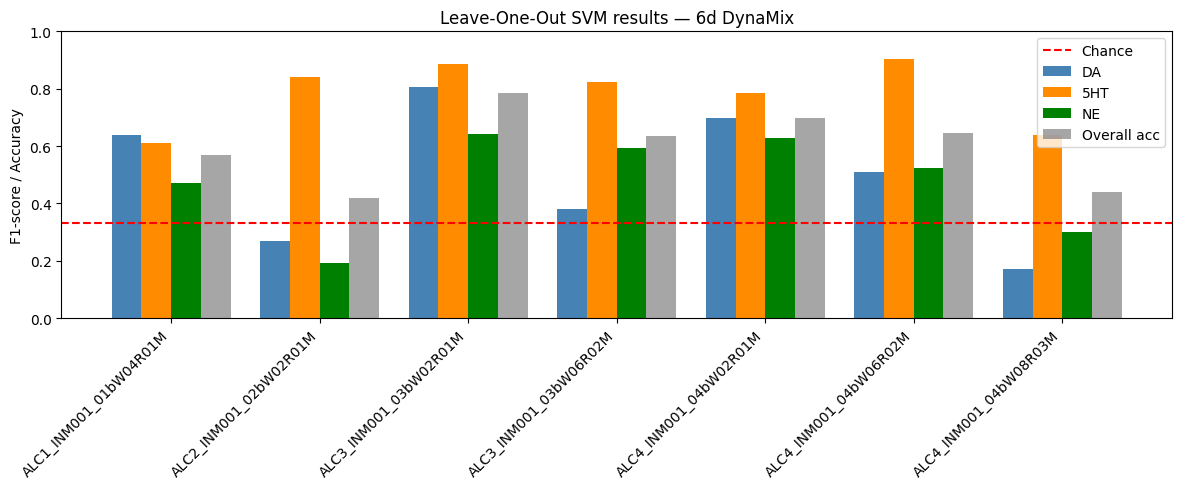

In [ ]:
plot_loo_results(svm_results_6d, model_dim='6d')

In [ ]:
def plot_model_comparison(results_3d, results_6d):
    metrics = ['DA', '5HT', 'NE', 'accuracy']
    
    def get_scores(results, metric):
        if metric == 'accuracy':
            return [v['acc'] for v in results.values()]
        return [v['report'][metric]['f1-score'] for v in results.values()]
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
    
    for ax, metric in zip(axes, metrics):
        scores_3d = get_scores(results_3d, metric)
        scores_6d = get_scores(results_6d, metric)
        
        ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
        ax.axhline(1/3, color='red', linestyle='--', alpha=0.5)
        ax.set_title(metric)
        ax.set_ylim(0, 1)
    
    axes[0].set_ylabel('Score')
    plt.suptitle('3d vs 6d DynaMix — Leave-one-out SVM cross-validation')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dro

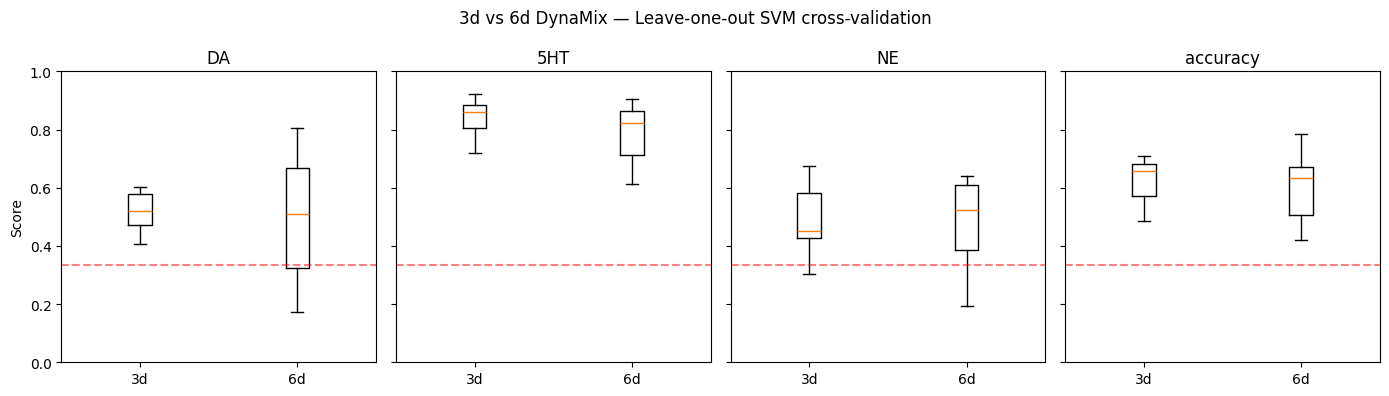

In [ ]:
plot_model_comparison(svm_results_3d, svm_results_6d)

# On Top-K time points

In [ ]:
k=8
t_k_peak_3d = np.argpartition(fold_3d,-k)[-k:]
t_k_peak_6d = np.argpartition(fold_6d,-k)[-k:]

In [ ]:
topk_svm_results_3d = loo_svm_tpeak(probe_list=probes,t_peak=t_k_peak_3d, k=k)
topk_svm_results_6d = loo_svm_tpeak(probe_list=probes,t_peak=t_k_peak_6d, k=k, model_dim=None)



Found 28 paths
Getting pairs collapsed.
First activation shape(35, 1000, 10)
First label shape(35, 4)
Expert activation set shape: (847, 1000, 10)
Labels shape: (847, 4)
Removed probes (all EQ/pH): []

Per-probe sample counts after filtering:
  ALCIS_155_macroREF__ALC1_INM001_01bW04R01M: 93 samples
  ALCIS_155_macroREF__ALC2_INM001_02bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC3_INM001_03bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW02R01M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW06R02M: 93 samples
  ALCIS_155_macroREF__ALC4_INM001_04bW08R03M: 93 samples
Total valid samples: 651
Available probe IDs:
['ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW02R01M'
 'ALCIS_155_macroREF__ALC3_INM001_03bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW02R01M'
 'ALCIS_155_macroREF__ALC4_INM001_04bW06R02M'
 'ALCIS_155_macroREF__ALC4_INM001_04

/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_3d, scores_6d], labels=['3d', '6d'])
/tmp/ipykernel_2394223/2097239291.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dro

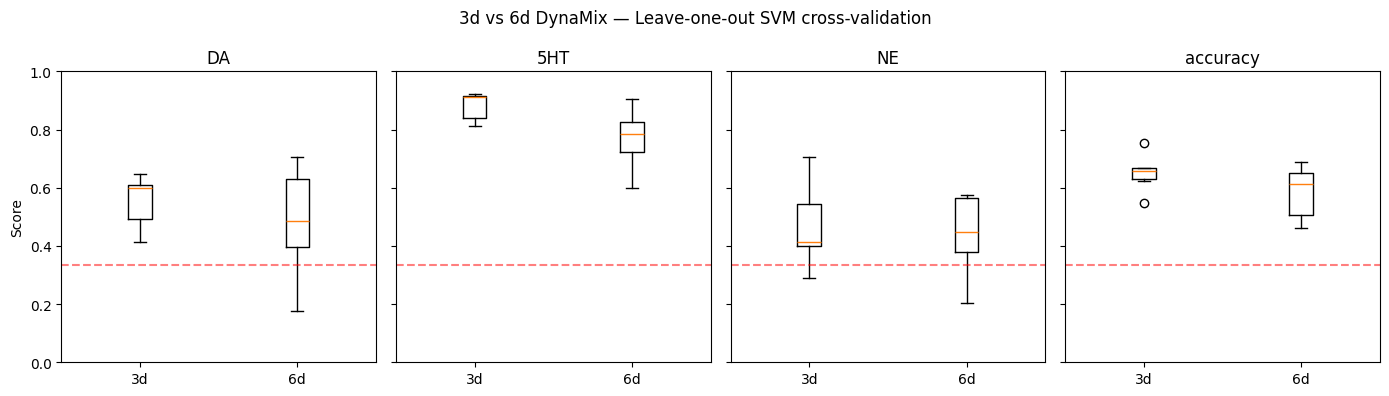

In [ ]:
plot_model_comparison(topk_svm_results_3d, topk_svm_results_6d)

# Old results

Text(0, 0.5, 'Accuracy')

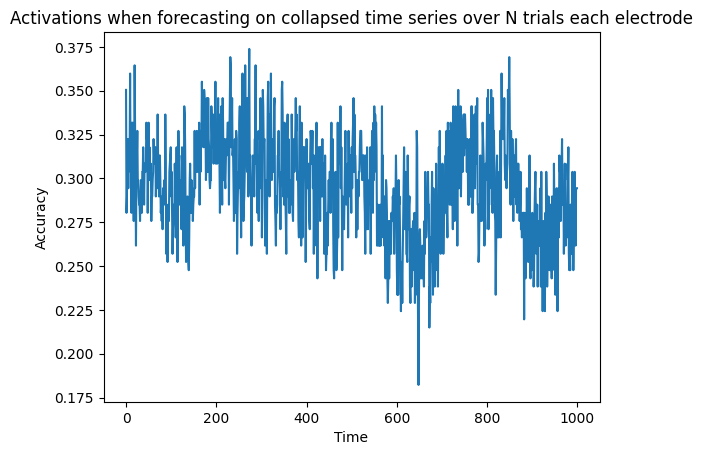

In [ ]:


plt.plot(range(T), acc_over_t_collapsed_over_electrode)
plt.title("Activations when forecasting on collapsed time series over N trials each electrode")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

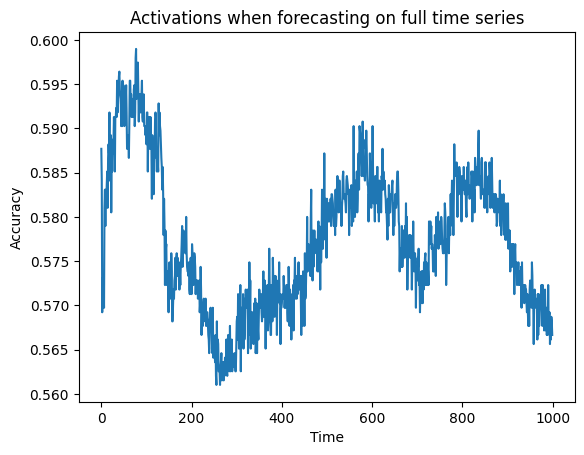

In [ ]:
plt.plot(range(T), acc_over_t_full)
plt.title("Activations when forecasting on full time series")
plt.xlabel("Time")
plt.ylabel("Accuracy")

In [ ]:
print(acc_full_mean)
print(acc_collapsed_mean)

0.5948717948717949
0.308411214953271
